In [1]:
from platform import python_version
print(python_version())

3.11.9


## Signed Pathways

### pseudo Modulationn Pathway Index (pMPI)

<p style="font-size: 20px; color: cyan;">
$pMPI = \log_2{ \frac{ \sum{Pos\_LFC_{i}}} { -\sum{Neg\_LFC_{i}}} }$
</p>

#### Example:

Suppose there are 10 DEGs in the inflammation pathway, as an example:

  - 8 up (g1 ... g8)
  - 2 dw (g9, g10)

PosLFC_sum = sum (  2 + 3 .... 4.2) = 32

NegLFC_sum = sum ( -3.5 + -4.5) = -8

pMPI = log2 (32/8) ~ log2 (4) = 2  

### Positive/Negative pMPI

#### pMPI >= +2 ~ indicates that, possibly, there are more Up than Downregulated genes
#### pMPI <= -2 ~ indicates that, possibly, there are more Down than Upregulated genes

#### Caveat: however, if there are Super Up or Dw LFCs (like outliers), pMPI will be distorted

#### -2 < pMPI < +2 .... balanced comparing the Up e Dw genes


In [2]:
import os, sys, pickle

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

import mygene

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# !pip install matplotlib-venn
import matplotlib_venn as venn
from matplotlib_venn import venn2, venn2_circles
%matplotlib inline

sys.path.insert(1, '../src/')

from Basic import *
from biopax_lib import *
from config_lib import *

pd.set_option("display.precision", 3)
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

email = "flalix@gmail.com"

In [3]:
root_chibe = "../../chibe/"
root_colab = '../../colaboracoes/'
root0      = '../../colaboracoes/aparecida/'

project = 'Medulloblastoma microarray study'
s_project = 'medulloblastoma'

gene_protein = 'dna'
s_omics = 'microarray'

has_age = False
has_gender = False

want_normalized = False
exp_normalization='quantile_norm' if want_normalized else None
normalization = 'not_normalized' if exp_normalization is None else exp_normalization

abs_lfc_cutoff_inf = 0.40
s_pathw_enrichm_method = 'enricher'
num_min_degs_for_ptw_enr=3

#------------ pathway pseudo-modulation index ------------
tolerance_pathway_index = 0.15
type_sat_ptw_index = 'linear_sat'
saturation_lfc_index = 5

case_list = ['WNT', 'G4']
case = case_list[0]

cfg = Config(project, s_project, case_list, root0)

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1
abs_lfc_cutoff, fdr_lfc_cutoff, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

pval_pathway_cutoff = 0.05
fdr_pathway_cutoff = .05
num_of_genes_cutoff = 3

print(f"G/P LFC cutoffs: lfc={abs_lfc_cutoff:.3f}; fdr={fdr_lfc_cutoff:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

G/P LFC cutoffs: lfc=1.000; fdr=0.050
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
pathway_name_id = 'Hemostasis - R-HSA-109582'
pathway_name_id = 'Regulation Of IGF Transport And Uptake By IGFBPs - R-HSA-381426'
pathway_name_id = 'Platelet degranulate - R-HSA-114608'
pathway_name_id = 'Platelet Activation, Signaling And Aggregation - R-HSA-76002'
pathway_name_id = 'Integrin Cell Surface Interactions - R-HSA-216083'
pathway_name_id = 'Neutrophil Degranulation - R-HSA-6798695'
pathway_name_id = 'Regulation of Complement cascade - R-HSA-977606'
pathway_name_id = 'Response To Elevated Platelet Cytosolic Ca2+ - R-HSA-76005'

bpx = Biopax(gene_protein, s_omics, project, s_project, root0,
             case_list, has_age, has_gender, clone_objects=False,
             exp_normalization=exp_normalization, geneset_num=0, 
             num_min_degs_for_ptw_enr=num_min_degs_for_ptw_enr, 
             tolerance_pathway_index=tolerance_pathway_index, 
             s_pathw_enrichm_method = s_pathw_enrichm_method,
             abs_lfc_cutoff_inf = abs_lfc_cutoff_inf, 
             type_sat_ptw_index=type_sat_ptw_index, saturation_lfc_index=saturation_lfc_index)

case = case_list[0]

bpx.cfg.set_default_best_lfc_cutoff(normalization, abs_lfc_cutoff=1, fdr_lfc_cutoff=0.05)
ret, degs, degs_ensembl, dfdegs = bpx.open_case(case, verbose=False)
print("\nEcho Parameters:")
bpx.echo_parameters()

geneset_num = bpx.geneset_num

Start opening tables ....
Building synonym dictionary ...


Echo Parameters:
For case 'WNT', there are 1043/766 DEGs/DEGs with ensembl_id
DEG's cutoffs: abs(LFC)=1.000; FDR=0.130
	1043/766 DEGs/ensembl.
		Up 340/218 DEGs/ensembl.
		Dw 703/548 DEGs/ensembl.

Found 68 (best=68) pathways for geneset num=0 'Reactome_2022'
Pathway cutoffs p-value=0.050 fdr=0.150 min genes=3
DEGs found in enriched pathways:
	There are 766 DEGs found in pathways
	279 (best=279) DEGs in pathways and 764/487 DEGs/ensembl not in pathways

	74 DEGs ensembl Up in pathways
	144 DEGs Up ensembl not in pathways

	205 DEGs ensembl Dw in pathways
	343 DEGs Dw ensembl not in pathways


In [5]:
df_enr = bpx.df_enr
print(len(df_enr))
df_enr.head(10)

68


,pathway,pathway_id,pval,fdr,odds_ratio,combined_score,genes,num_of_genes
0,Neuronal System,R-HSA-112316,1.323e-20,1.388e-17,4.929,225.617,"['RAB3A', 'KCNK9', 'RASGRF1', 'GRM1', 'RIMS1', 'GRM5', 'LRRTM3', 'LRRTM4', '...",60
1,Signal Transduction,R-HSA-162582,1.256e-11,6.586e-09,1.923,48.266,"['FOXA1', 'CPNE8', 'SH3GL3', 'RTKN', 'AMHR2', 'HDAC11', 'FZD10', 'FGF1', 'NR...",159
2,Neurotransmitter Release Cycle,R-HSA-112310,3.382e-09,1.183e-06,9.928,193.644,"['RAB3A', 'SLC32A1', 'GLS2', 'GAD1', 'SLC1A1', 'GAD2', 'LIN7A', 'SYN3', 'SLC...",14
3,Transmission Across Chemical Synapses,R-HSA-112315,5.979e-09,1.568e-06,3.731,70.646,"['CHRNA3', 'RAB3A', 'CHRNA5', 'GLS2', 'SLC1A1', 'RASGRF1', 'LIN7A', 'SLC1A6'...",31
4,Potassium Channels,R-HSA-1296071,9.723e-09,2.040e-06,5.869,108.271,"['HCN4', 'KCNJ5', 'KCNH6', 'KCNK10', 'KCNK9', 'KCND2', 'KCNJ8', 'KCNH8', 'KC...",19
5,Protein-protein Interactions At Synapses,R-HSA-6794362,3.303e-08,5.774e-06,6.126,105.525,"['MPP3', 'NRXN3', 'LIN7A', 'GRM1', 'GRIN2D', 'LRFN2', 'GRM5', 'PPFIBP2', 'LR...",17
6,Cardiac Conduction,R-HSA-5576891,1.489e-06,2.232e-04,4.262,57.179,"['RYR2', 'KCNK10', 'KCNK9', 'KCND2', 'GATA4', 'KCNA5', 'KCNK17', 'ATP2B1', '...",18
7,Signaling By Receptor Tyrosine Kinases,R-HSA-9006934,3.466e-06,4.544e-04,2.334,29.345,"['SH3GL3', 'SHC2', 'FLT1', 'LAMA1', 'LAMA4', 'FGF1', 'THBS4', 'THBS3', 'FGF5...",41
8,Repression Of WNT Target Genes,R-HSA-4641265,7.140e-06,8.322e-04,18.973,224.826,"['TLE2', 'TLE1', 'MYC', 'LEF1', 'TCF7', 'AXIN2']",6
9,Neurexins And Neuroligins,R-HSA-6794361,8.927e-06,9.364e-04,6.077,70.658,"['GRM5', 'MPP3', 'LRRTM3', 'SYT12', 'LRRTM4', 'EPB41L2', 'NRXN3', 'LIN7A', '...",11


### Pathway Gene Index

### calc_all_pathway_gene_indexes()

In [6]:
force = False
verbose = False

dff = bpx.calc_all_pathway_gene_indexes(force=force, verbose=verbose)
print(dff.shape)
dff.iloc[:4, :9]

(238, 15)


,case,pathway_id,pathway,mod_pathway_index,ratio_up_dw,n_genes_annot_in_pathway,n_mod_in_pathway,perc_mod_in_pathway,n_mod_up_in_pathway
0,WNT,R-HSA-4411364,Binding of TCF/LEF:CTNNB1 to target gene promoters,2.229,4.687,8,8,1.000,5
1,WNT,R-HSA-8951430,RUNX3 regulates WNT signaling,2.044,4.123,8,8,1.000,5
2,WNT,R-HSA-4641263,Regulation of FZD by ubiquitination,1.109,2.157,21,18,0.857,12
3,WNT,R-HSA-4641265,Repression of WNT target genes,1.089,2.127,14,13,0.929,9


### Pivot Table

In [8]:
dfpiv, dff, text_all, df_sum_ptw = bpx.calc_pMPI_pivot_summary(force=False, verbose=False)
print(len(df_sum_ptw))
df_sum_ptw.head(2)

dfpiv

238


case,G4,WNT
pathway,,
ADORA2B mediated anti-inflammatory cytokines production,-1.367,-1.121
Activated point mutants of FGFR2,-2.497,-1.308
Activation of BH3-only proteins,0.052,0.251
Activation of Matrix Metalloproteinases,0.972,-0.229
Activation of TRKA receptors,-2.957,-0.372
...,...,...
Transport of inorganic cations/anions and amino acids/oligopeptides,-1.515,-1.238
Transport of small molecules,-0.962,-0.824
Type I hemidesmosome assembly,-0.391,-0.388


In [9]:
want_print = False

if want_print:
    for pathway in dfpiv.index:
        print(pathway)

In [10]:

set_synaptic = ['Synaptic adhesion-like molecules',  'Presynaptic depolarization and calcium channel opening',
                'Neurotransmitter receptors and postsynaptic signal transmission',  
                'Protein-protein interactions at synapses',  'Transmission across Chemical Synapses',]

#                 'Activation of NMDA receptors and postsynaptic events',          'LGI-ADAM interactions'

set_inflammation = ['ADORA2B mediated anti-inflammatory cytokines production',
                    'Anti-inflammatory response favouring Leishmania parasite infection',
                     'Leishmania infection',]
# MECP2 muation - neural development
# https://reactome.org/content/detail/R-HSA-8986944
set_neural_system = ['Neurexins and neuroligins', 'Neuronal System',
                     # https://reactome.org/content/detail/R-HSA-9031628
                     # In rat PC12 cells, a common model for NGF signaling, stimulation with NGF causes cells to exit the cell cycle and undergo a differentiation program leading to neurite outgrowth. 
                     'NCAM signaling for neurite out-growth', 'NGF-stimulated transcription',  'NGF-independant TRKA activation',
                     'NCAM1 interactions', 'Ion homeostasis', 
                     'Transcriptional Regulation by MECP2',  'MECP2 regulates transcription factors',
                     'Phase 4 - resting membrane potential',]

# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7564905/
# Neurotrophins are a family of proteins known for regulating nervous system development and neuronal survival and plasticity. These proteins act by activating specific receptor proteins on the cell surface. More recently, neurotrophins and their receptors emerged as mechanisms contributing to cancer progression.

# TRKA == NTRK1 Neurotrophic Receptor Tyrosine Kinase 1
# REFSEQ; This gene encodes a member of the neurotrophic tyrosine kinase receptor (NTKR) family. This kinase is a membrane-bound receptor that, upon neurotrophin binding, phosphorylates itself and members of the MAPK pathway.

# Neurotrophins are a family of growth factors related to nerve growth factor, NGF, and found within the central and peripheral nervous system. Neurotrophins can be produced by muscle cells and retrogradely transported to motor neuron cell bodies with neurotrophin receptors
# An important function of the kinase cascade triggered by neurotrophins is to induce the phosphorylation and activation of transcription factors in the nucleus to initiate new programs of gene expression. 
# https://reactome.org/PathwayBrowser/#/R-HSA-198725

# NTRK gene fusions as novel targets of cancer therapy across multiple tumour types
# https://www.sciencedirect.com/science/article/pii/S2059702920325795
# The binding of TrkA receptor by NGF causes the activation of the Ras/Mitogen activated protein kinase (MAPK) pathway, which leads to increased proliferation and cellular growth through extracellular signal-regulated kinase (ERK) signalling. 

# https://reactome.org/PathwayBrowser/#/R-HSA-5684996
# extracellular signal regulated kinases (ERKs) 1 and 2, also known as MAPK3 and MAPK1, ar

set_wnt = ['RUNX3 regulates WNT signaling',  'Repression of WNT target genes', 'Signaling by WNT', 
           'TCF dependent signaling in response to WNT', 'Binding of TCF/LEF:CTNNB1 to target gene promoters',
           'Deactivation of the beta-catenin transactivating complex',  'Regulation of FZD by ubiquitination',]


set_gpcr = ['Signaling by GPCR',  'GPCR downstream signalling',  
            'G alpha (i) signalling events', 'G alpha (s) signalling events', 'G alpha (z) signalling events', 
            'Class B/2 (Secretin family receptors)', 'DAG and IP3 signaling', 'Effects of PIP2 hydrolysis', 
            'Phospholipase C-mediated cascade: FGFR1', 'Phospholipase C-mediated cascade; FGFR2',  'Activated point mutants of FGFR2',]

set_fgfr = ['Signaling by activated point mutants of FGFR1', 
            'FGFR1 ligand binding and activation', 'FGFR1c ligand binding and activation',
            'FGFR3 ligand binding and activation', 'FGFR3 mutant receptor activation',
            'Phospholipase C-mediated cascade: FGFR1', 'Phospholipase C-mediated cascade; FGFR2',  'Activated point mutants of FGFR2',]


set_ngf_trka = ['Nuclear Events (kinase and transcription factor activation)',
                'Signaling by NTRK1 (TRKA)',
                'NGF-independant TRKA activation', 'NGF-stimulated transcription',
                'RAF/MAP kinase cascade',  'DAG and IP3 signaling',
                'MAPK family signaling cascades', 'MAPK1/MAPK3 signaling', ]

# Neurotrophin Signaling in Medulloblastoma
# Unravelling the Mechanism of TrkA-Induced Cell Death by Macropinocytosis in Medulloblastoma Daoy Cells
# may play a role in specifying sensory neuron subtypes.
set_pi3k_ativation = ['Negative regulation of the PI3K/AKT network',  'PI5P, PP2A and IER3 Regulate PI3K/AKT Signaling',
                      'Constitutive Signaling by Aberrant PI3K in Cancer',   'RHOA GTPase cycle',]

set_neurotransmiter = [ 'GABA synthesis, release, reuptake and degradation',  'Dopamine Neurotransmitter Release Cycle',
                        'Glutamate Neurotransmitter Release Cycle', 'Neurotransmitter release cycle',
                        'Serotonin Neurotransmitter Release Cycle', 'Opioid Signalling']

set_gtpase = [ 'CDC42 GTPase cycle',  'RAC1 GTPase cycle', 'RHO GTPase cycle', 'RHOA GTPase cycle', 'RHOD GTPase cycle', 'RHOG GTPase cycle',
              'Signaling by Rho GTPases', 'Signaling by Rho GTPases, Miro GTPases and RHOBTB3',]

set_potassium_channel = ['Potassium Channels', 'Tandem pore domain potassium channels',
                         'Voltage gated Potassium channels' ]

set_platelete = [ 'Platelet activation, signaling and aggregation',  'Platelet calcium homeostasis', 'Platelet homeostasis', 
                 'Hemostasis',]

set_apoptosis = [ 'Activation of BH3-only proteins',  'NRAGE signals death through JNK',]

set_syndromes = [ 'Defective B3GALTL causes PpS',  'Diseases associated with O-glycosylation of proteins',]

set_mmp = ['Degradation of the extracellular matrix', 'Extracellular matrix organization',
           'Activation of Matrix Metalloproteinases',  'Type I hemidesmosome assembly',
           'Assembly of collagen fibrils and other multimeric structures',  
           'Collagen chain trimerization',  'Collagen formation',]


set_collagen = [ 'Assembly of collagen fibrils and other multimeric structures',  
                 'Collagen chain trimerization',  'Collagen formation',]
# 'Collagen biosynthesis and modifying enzymes'

set_ecm = ['Degradation of the extracellular matrix', 'Extracellular matrix organization',
           'Activation of Matrix Metalloproteinases',  'Type I hemidesmosome assembly',]


set_transport = ['Amino acid transport across the plasma membrane',
                 'Transport of inorganic cations/anions and amino acids/oligopeptides',
                 'Transport of small molecules',  'SLC-mediated transmembrane transport',
                 'Ion homeostasis',  'Proton-coupled monocarboxylate transport',]

set_lipid = [ 'HDL remodeling',  'Phospholipid metabolism',]

set_metabolism = ['Phospholipid metabolism', 
                  'Creatine metabolism',  'Glycosaminoglycan metabolism',
                  'Keratan sulfate/keratin metabolism',  'Keratan sulfate biosynthesis',
                  'Synthesis of 5-eicosatetraenoic acids',  'RA biosynthesis pathway',]


set_diseases = ['DSCAM interactions',  'Anti-inflammatory response favouring Leishmania parasite infection',
                'Leishmania infection',]

set_insulin = [ 'Glucagon-like Peptide-1 (GLP1) regulates insulin secretion',]


set_glycozilation = [ 'O-glycosylation of TSR domain-containing proteins', 
                     'Diseases associated with O-glycosylation of proteins',]

set_cardio = ['Cardiac conduction', 'Muscle contraction']

# https://reactome.org/content/detail/R-HSA-157118
set_sensory = ['Sensory processing of sound',  'Sensory processing of sound by inner hair cells of the cochlea',
               'Sensory processing of sound by outer hair cells of the cochlea', ]

set_nuclear_receptors = [ 'Scavenging by Class A Receptors',  'Binding and Uptake of Ligands by Scavenger Receptors',]


set_signal_transd = ['Signal Transduction', 'Signaling by GPCR',  'GPCR downstream signalling',  
                     'Signaling by NOTCH1', 'Signaling by NTRK1 (TRKA)', 'Signaling by Receptor Tyrosine Kinases',
                     'Signaling by Retinoic Acid', 
                     'G alpha (i) signalling events', 'G alpha (s) signalling events',  'G alpha (z) signalling events',
                     'Nucleotide-like (purinergic) receptors', 
                     'Signaling by Receptor Tyrosine Kinases',  'Receptor-type tyrosine-protein phosphatases',
                     'Signaling by WNT', 'Integrin cell surface interactions', 
                     'Signaling by activated point mutants of FGFR1', 
                     'FGFR1 ligand binding and activation', 'FGFR1c ligand binding and activation',
                     'FGFR3 ligand binding and activation', 'FGFR3 mutant receptor activation',]

set_integrings_laminins = ['Laminin interactions', 'Integrin cell surface interactions', ]

set_notch = ['Signaling by NOTCH1', 'NOTCH2 intracellular domain regulates transcription', 
             'NOTCH3 Intracellular Domain Regulates Transcription',
             'NOTCH4 Intracellular Domain Regulates Transcription',]



#  'Signaling by NTRKs',

set_tyrosine_kyn = ['Activation of TRKA receptors', 'NGF-independant TRKA activation',  'Signaling by NTRK1 (TRKA)',
                    'Signaling by Receptor Tyrosine Kinases',  ]

set_gap_junction = [ 'Gap junction assembly', 'Gap junction trafficking', 'Gap junction trafficking and regulation',]

set_acqua = [ 'Vasopressin regulates renal water homeostasis via Aquaporins',]

### Plot heatmap

In [11]:
row_height = 50
header_height = 200

force=True
verbose=False

type_modulation='similar'
type_modulation='different'
type_modulation='all'

at_least=2; diff_cutoff=2

In [12]:
set_synaptic

['Synaptic adhesion-like molecules',
 'Presynaptic depolarization and calcium channel opening',
 'Neurotransmitter receptors and postsynaptic signal transmission',
 'Protein-protein interactions at synapses',
 'Transmission across Chemical Synapses']

In [13]:
lista = [[x, bpx.which_reacotme_id(x)] for x in set_synaptic]
lista

[['Synaptic adhesion-like molecules', 'R-HSA-8849932'],
 ['Presynaptic depolarization and calcium channel opening', 'R-HSA-112308'],
 ['Neurotransmitter receptors and postsynaptic signal transmission',
  'R-HSA-112314'],
 ['Protein-protein interactions at synapses', 'R-HSA-6794362'],
 ['Transmission across Chemical Synapses', 'R-HSA-112315']]

In [14]:
pathway_and_id = lista[0]
print(pathway_and_id)

dfpiv, dff = bpx.calc_pivot_one_pathway_gene_modulations(pathway_and_id, verbose=False)

['Synaptic adhesion-like molecules', 'R-HSA-8849932']


In [15]:
dfpiv.columns

Index(['G4', 'WNT'], dtype='object', name='case')

### WNT



 RUNX3 regulates WNT signaling R-HSA-8951430 



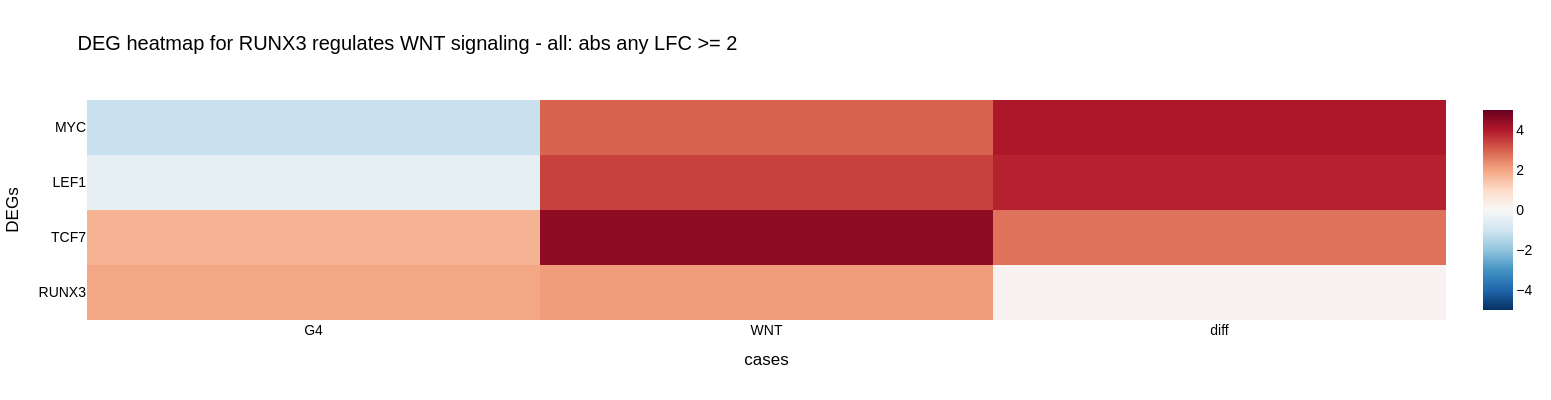



 Repression of WNT target genes R-HSA-4641265 



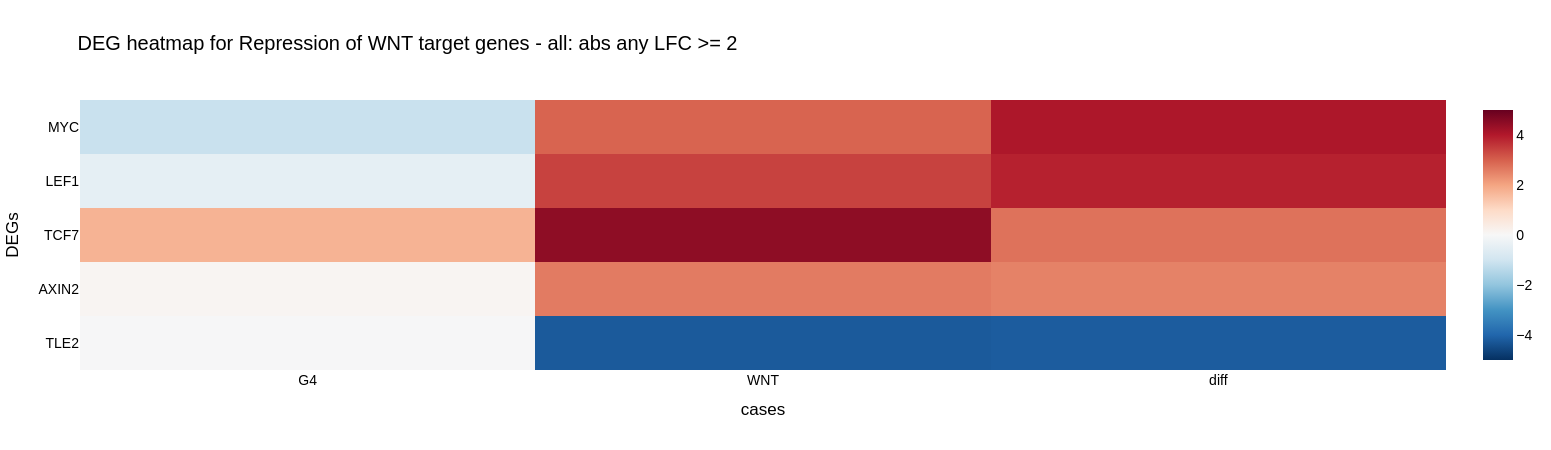



 Signaling by WNT R-HSA-195721 



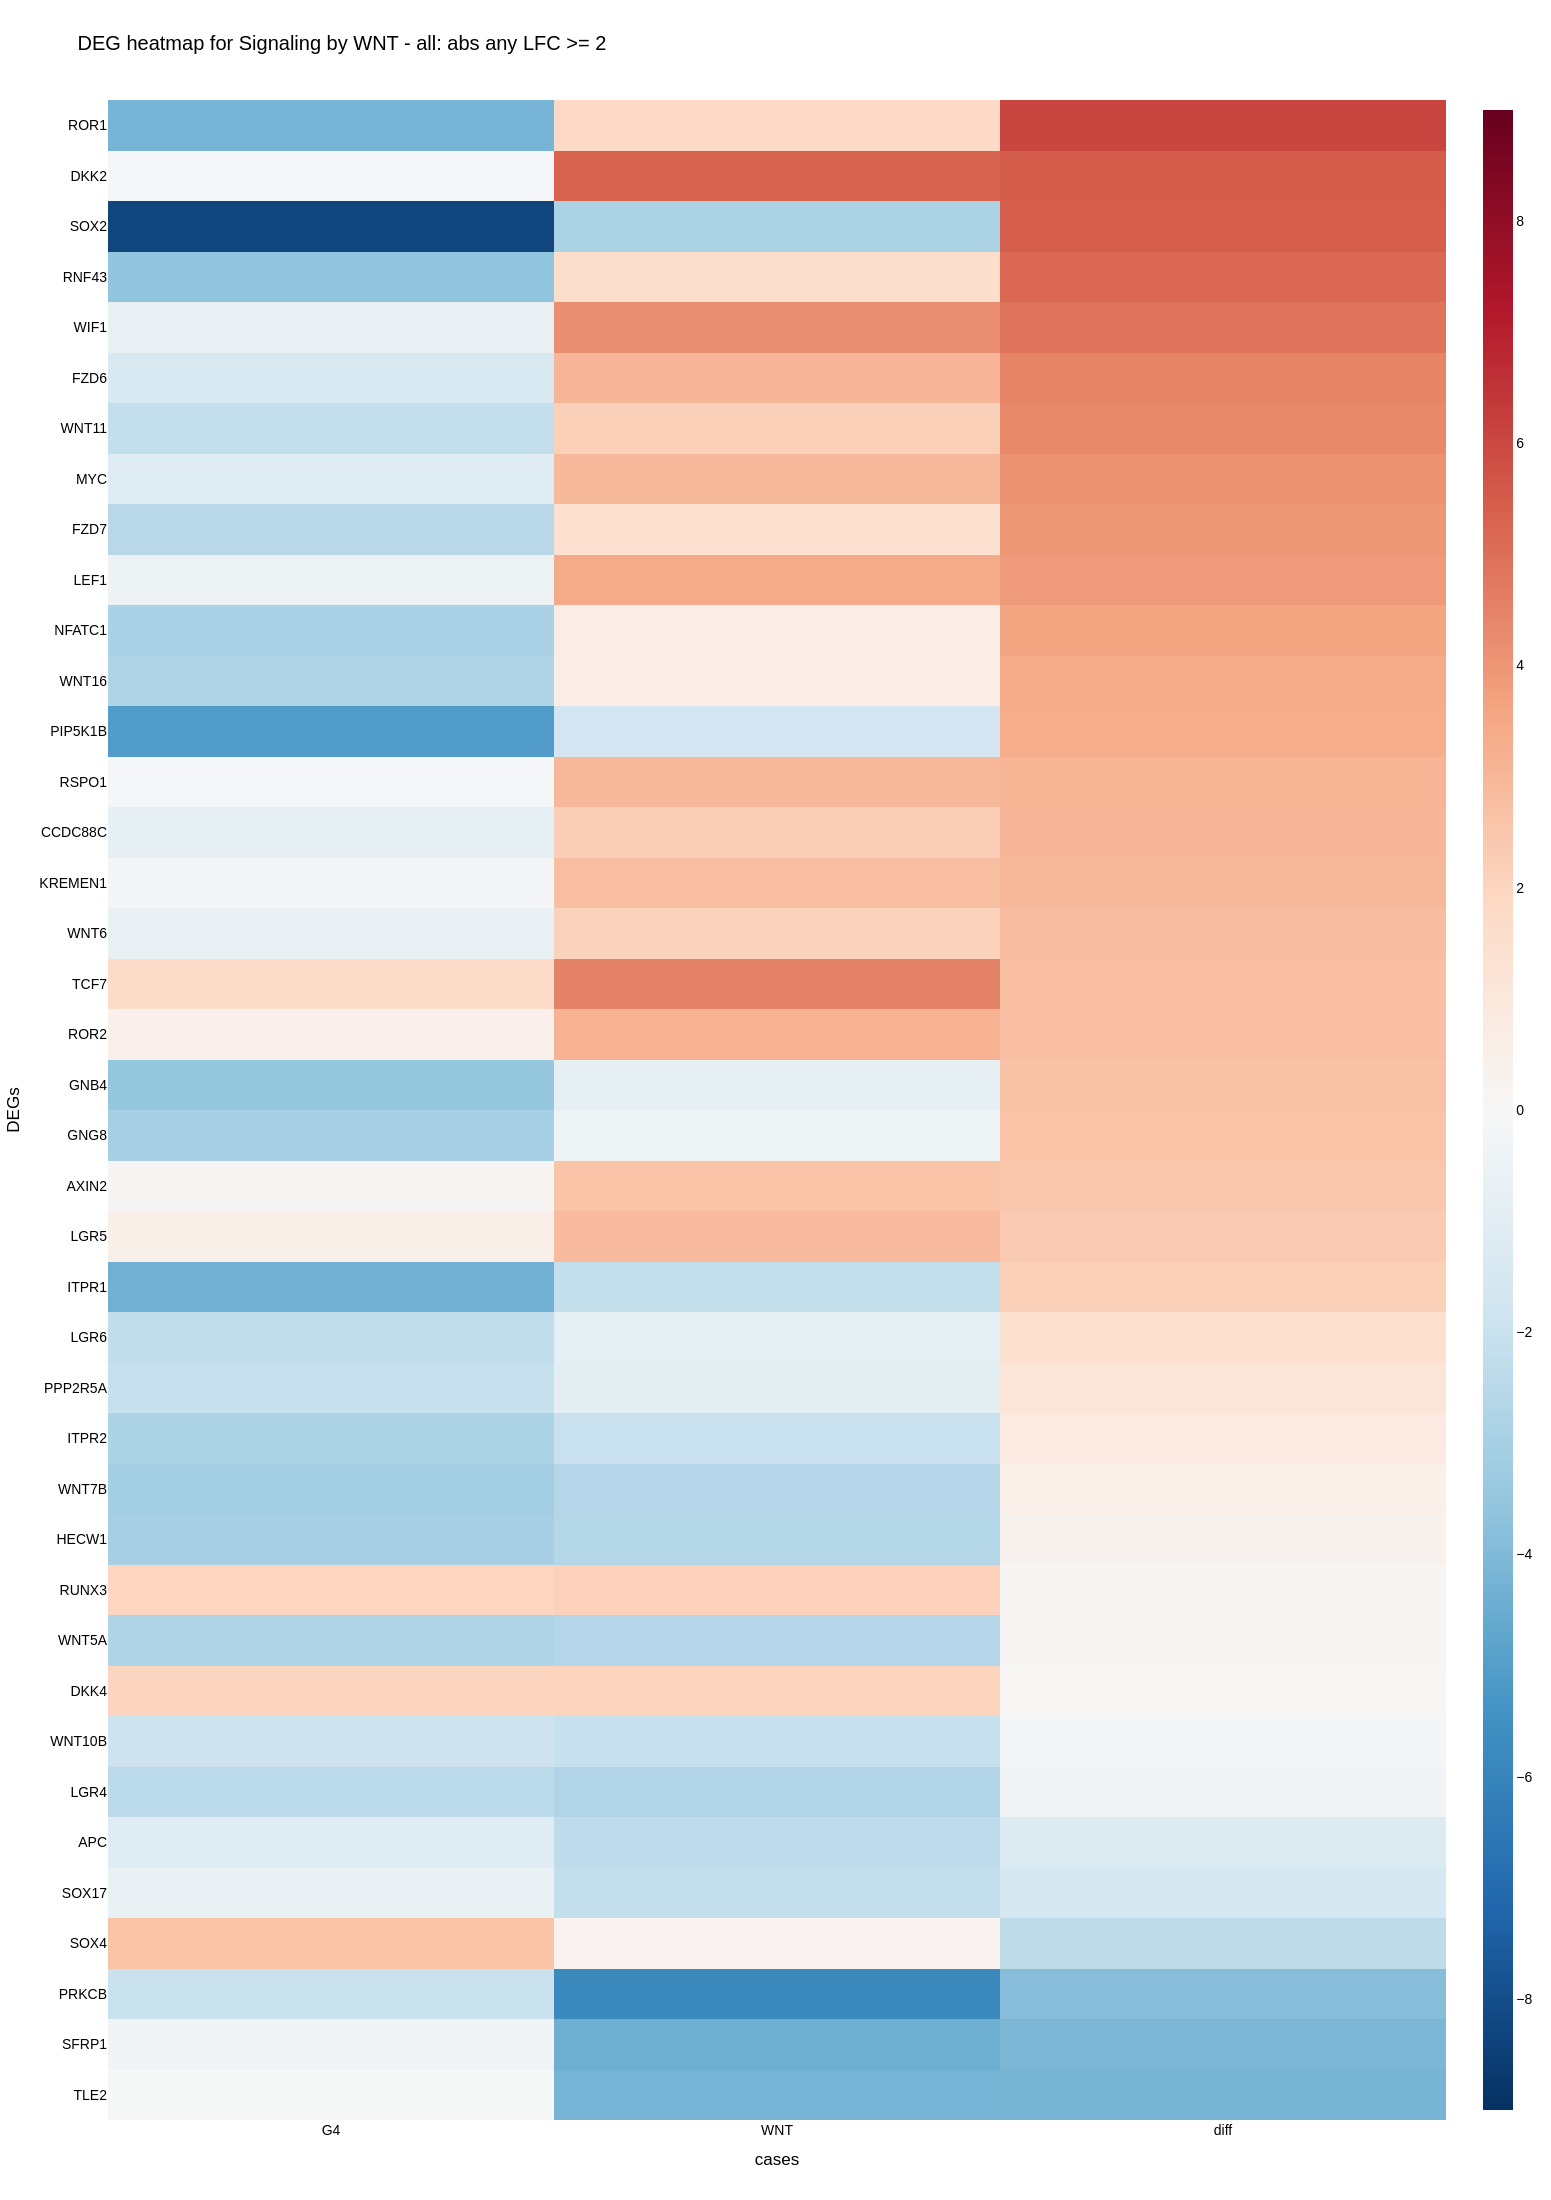



 TCF dependent signaling in response to WNT R-HSA-201681 



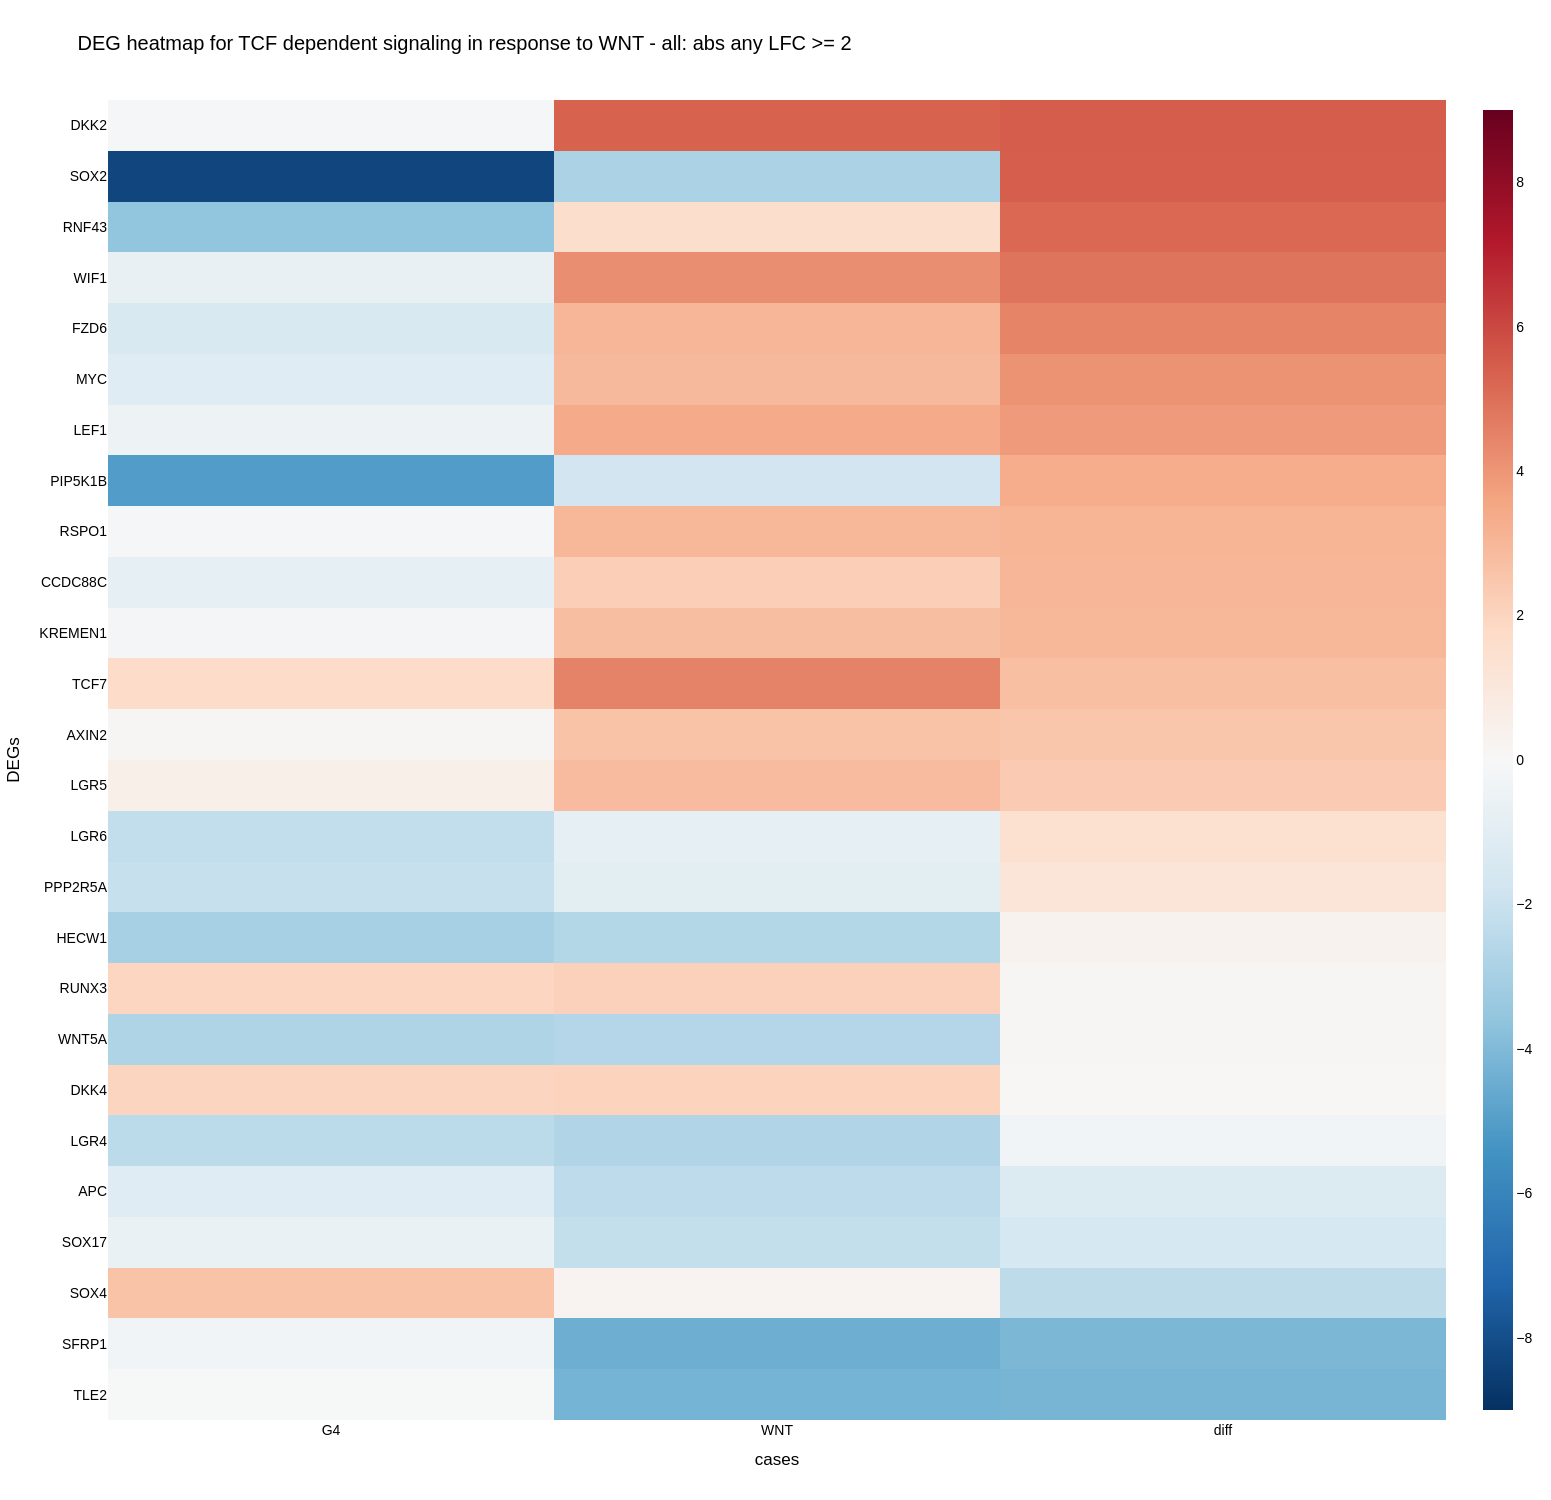



 Binding of TCF/LEF:CTNNB1 to target gene promoters R-HSA-4411364 



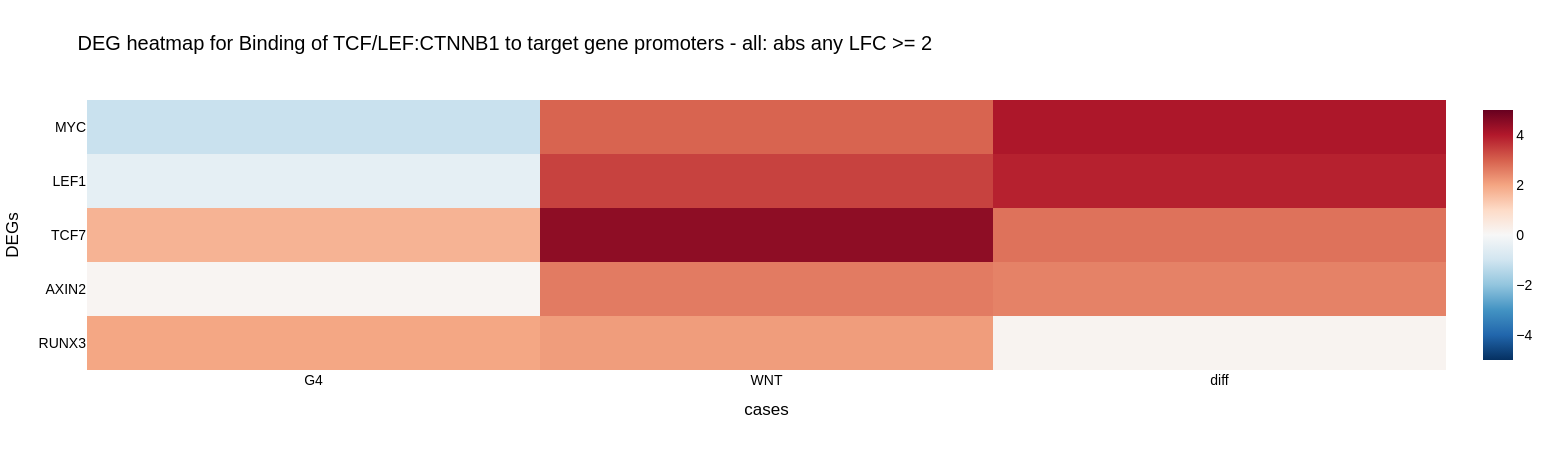



 Deactivation of the beta-catenin transactivating complex R-HSA-3769402 



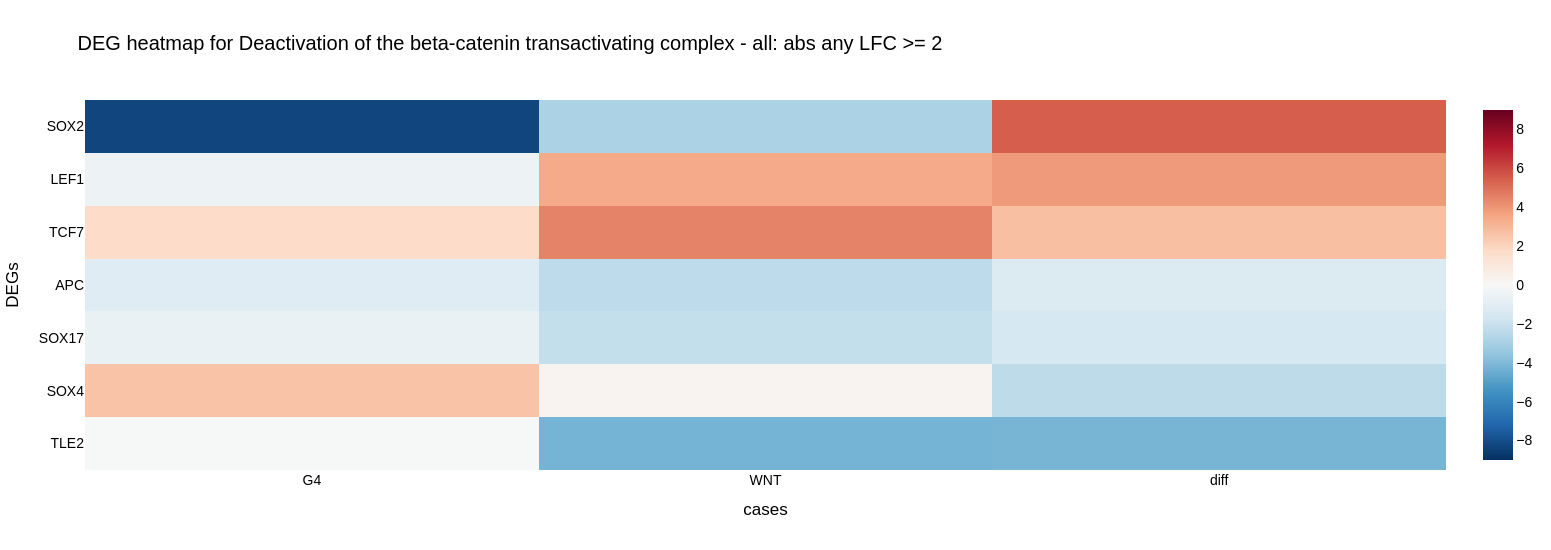



 Regulation of FZD by ubiquitination R-HSA-4641263 



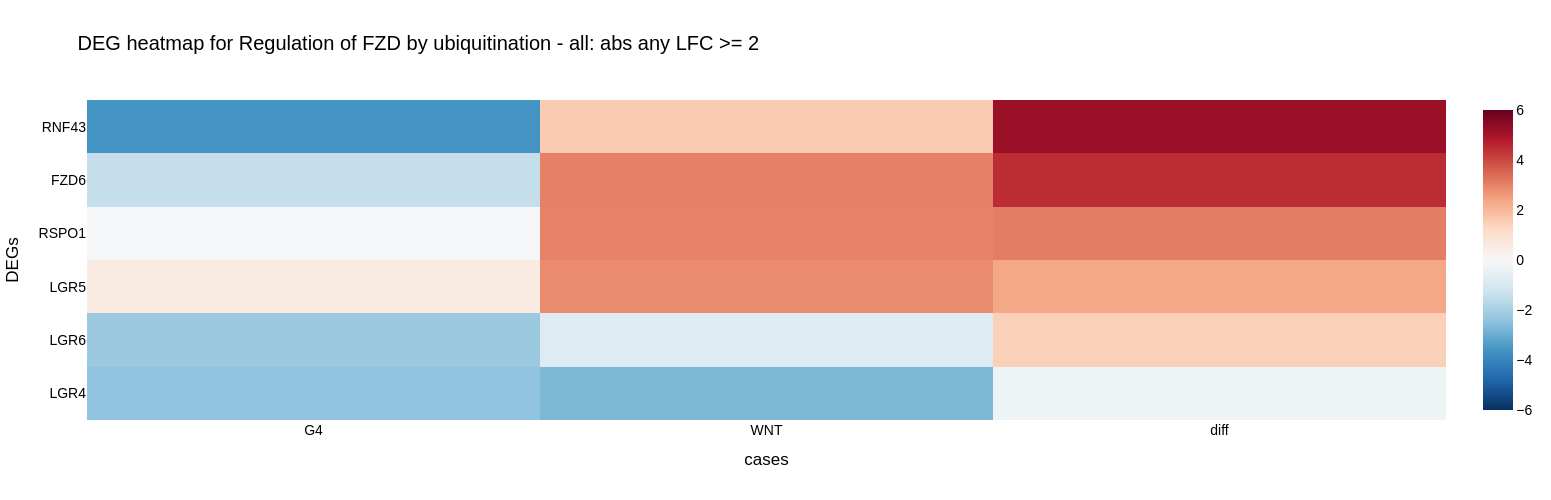

In [18]:
lista = [[x, bpx.which_reacotme_id(x)] for x in set_wnt]

type_modulation='different'
type_modulation='similar'
type_modulation='all'

for pathway_and_id in lista:
    pathway, pathway_id = pathway_and_id
    print('\n\n', pathway, pathway_id, '\n')

    fig, dff, dfpiv = bpx.plot_one_pathway_genes_heatmap_by_cases(pathway_and_id, type_modulation=type_modulation, diff_cutoff=diff_cutoff,
                                                                  zlim=None, width=800, row_height=row_height, header_height=header_height, horizontal_spacing=0.20)

    if fig is None: continue

    fig.show()

### NGF - TRKA



 Nuclear Events (kinase and transcription factor activation) R-HSA-198725 



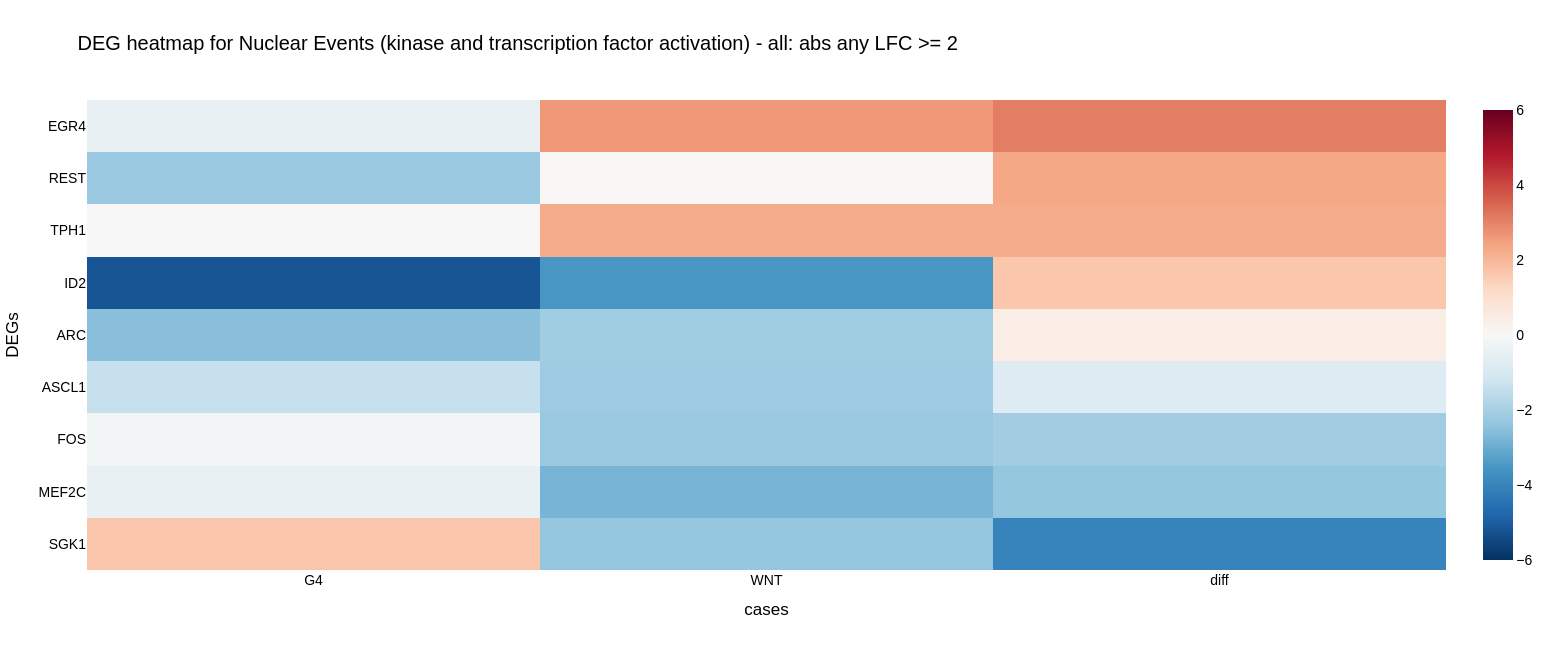



 Signaling by NTRK1 (TRKA) R-HSA-187037 



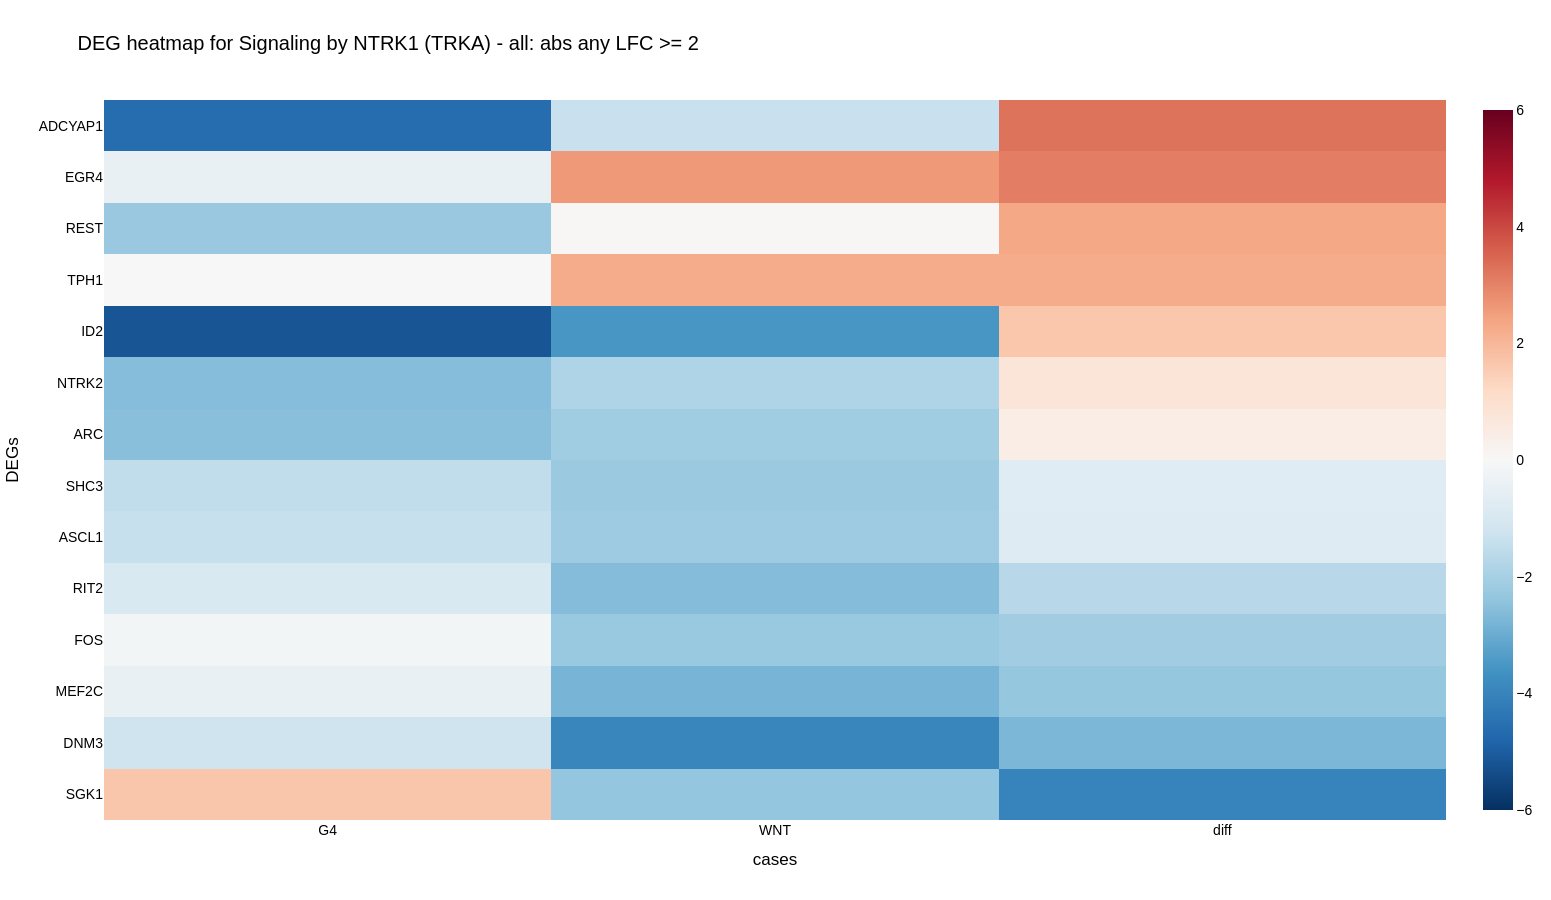



 NGF-independant TRKA activation R-HSA-187024 



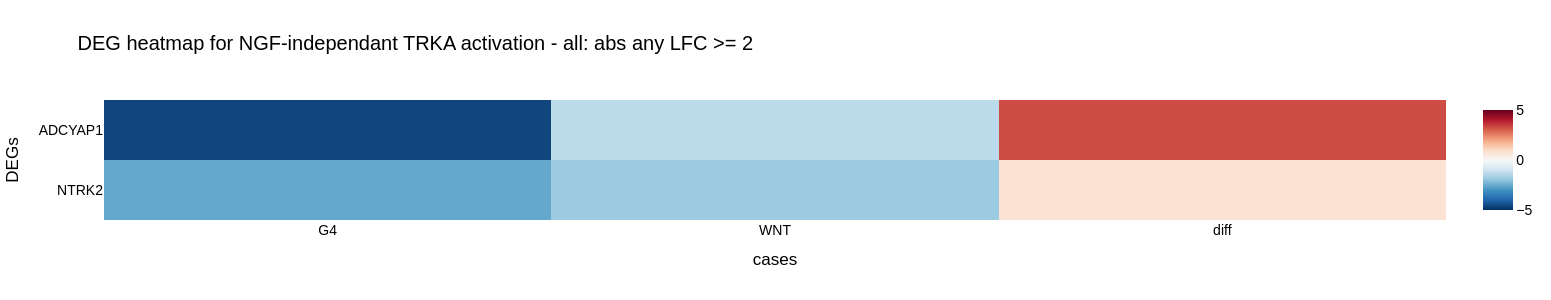



 NGF-stimulated transcription R-HSA-9031628 



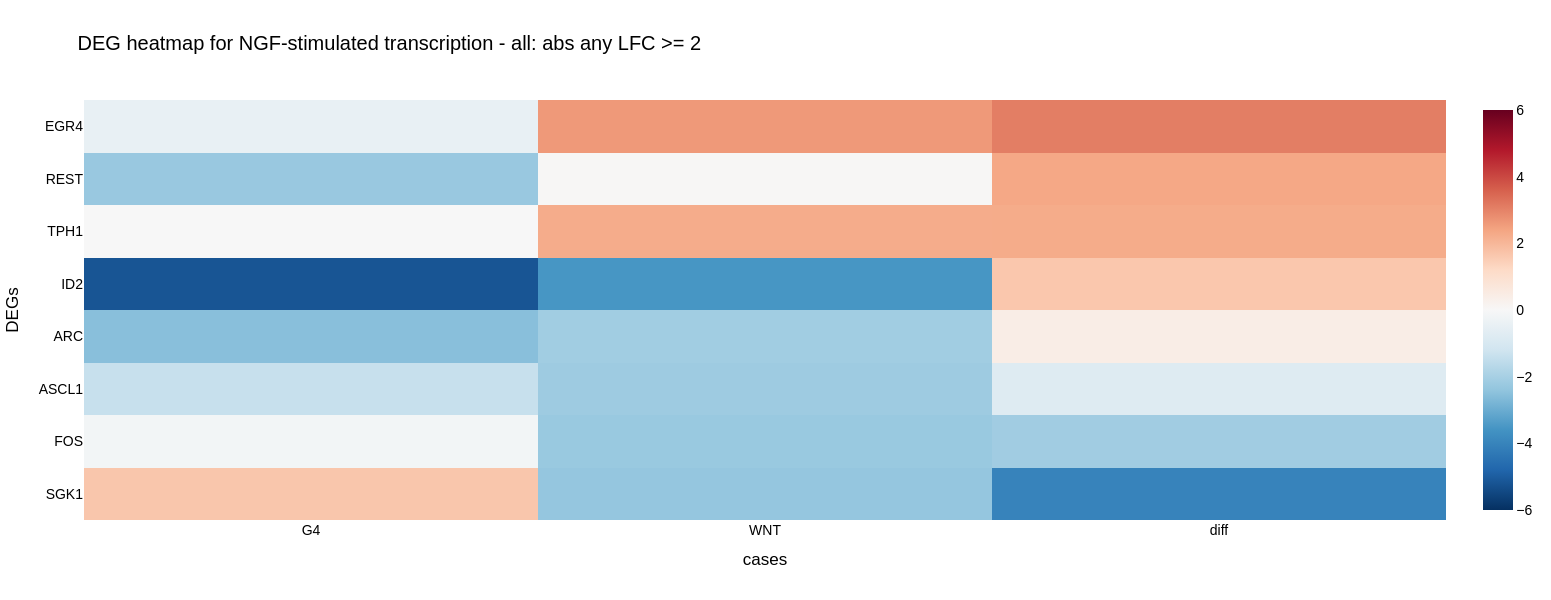



 RAF/MAP kinase cascade R-HSA-5673001 



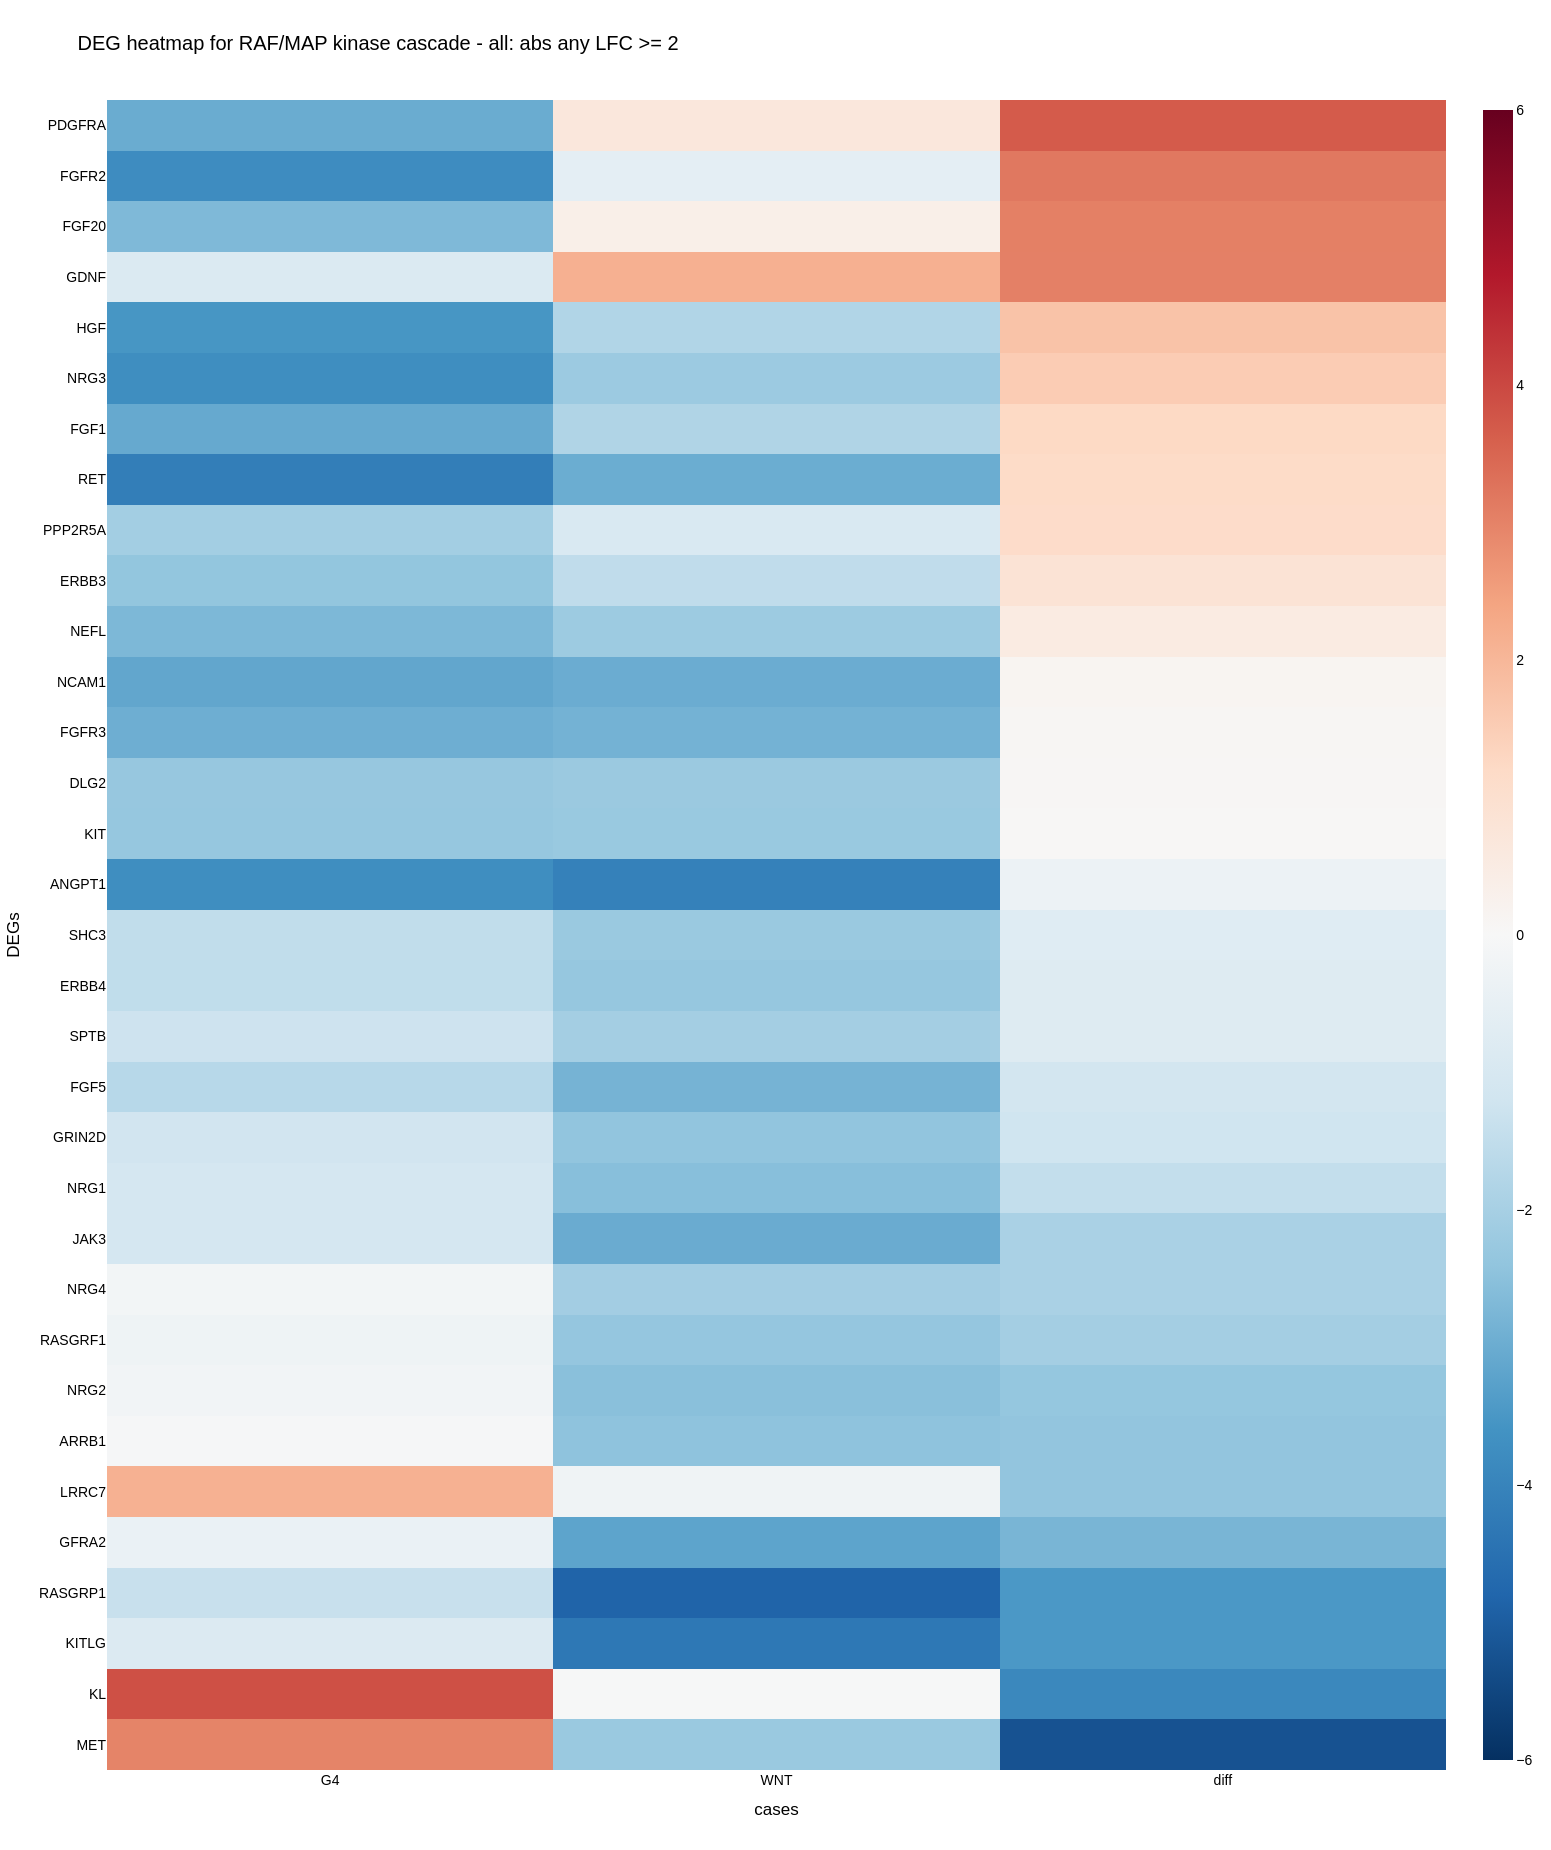



 DAG and IP3 signaling R-HSA-1489509 



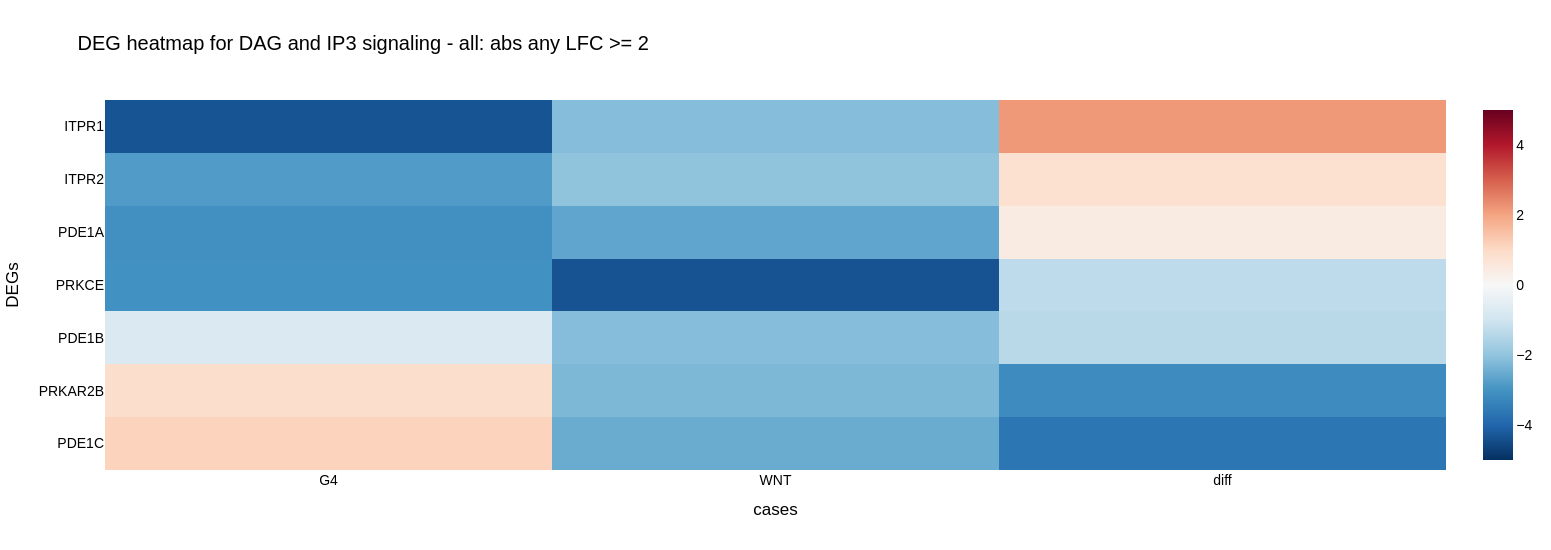



 MAPK family signaling cascades R-HSA-5683057 



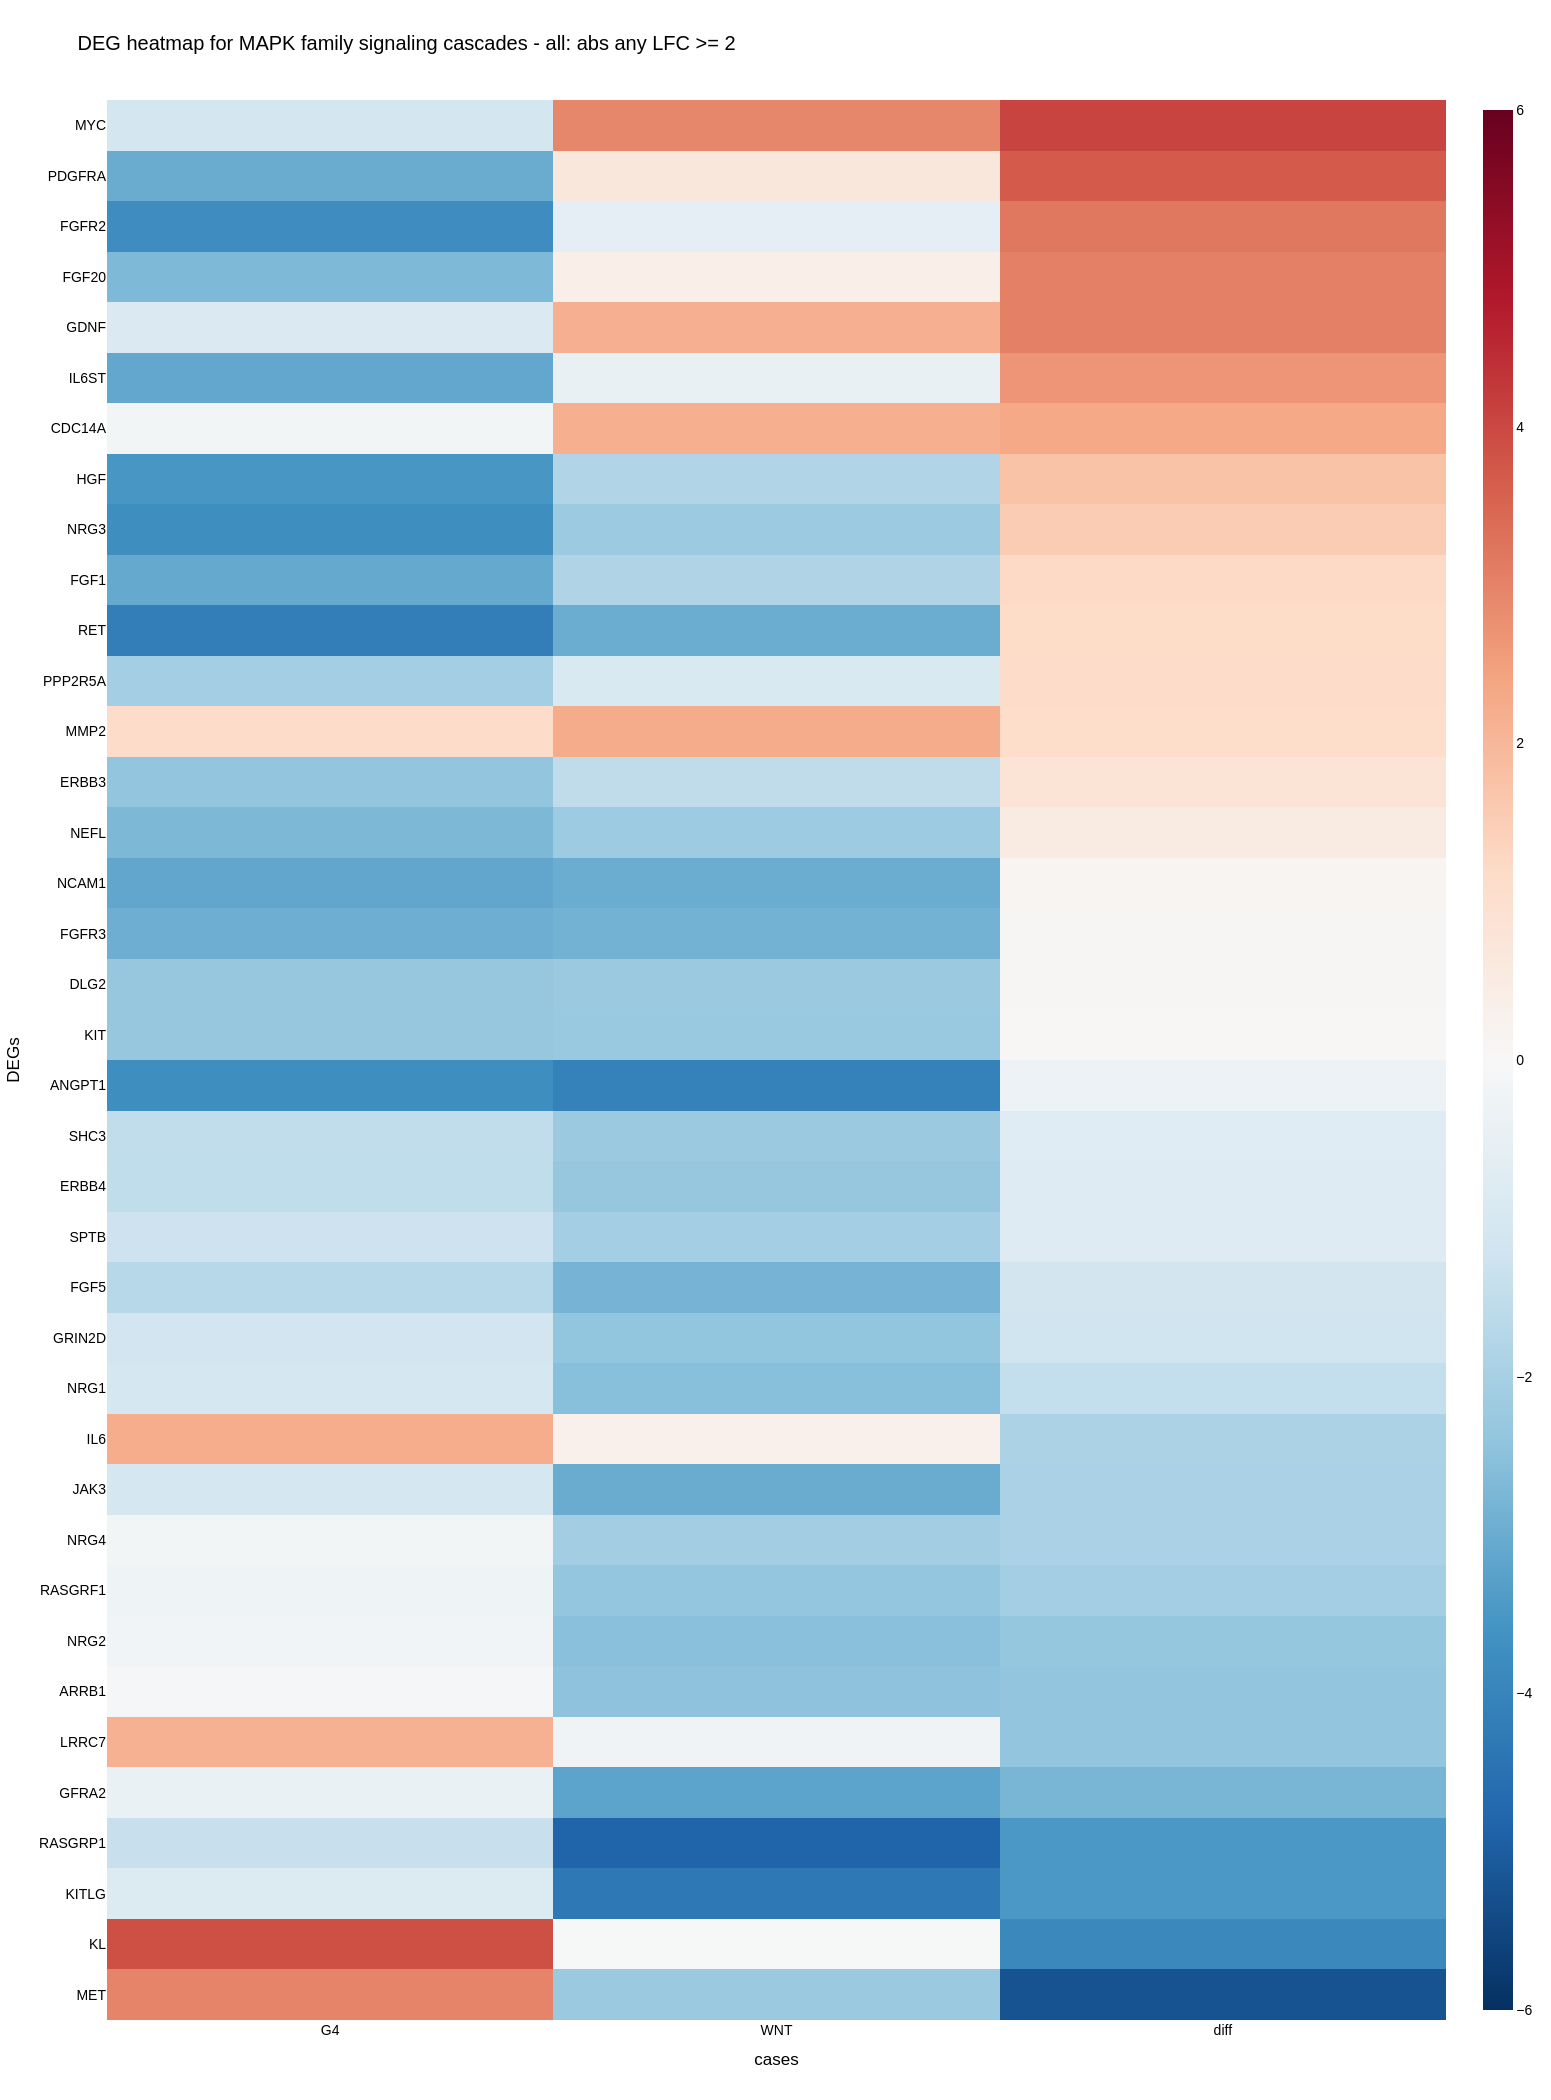



 MAPK1/MAPK3 signaling R-HSA-5684996 



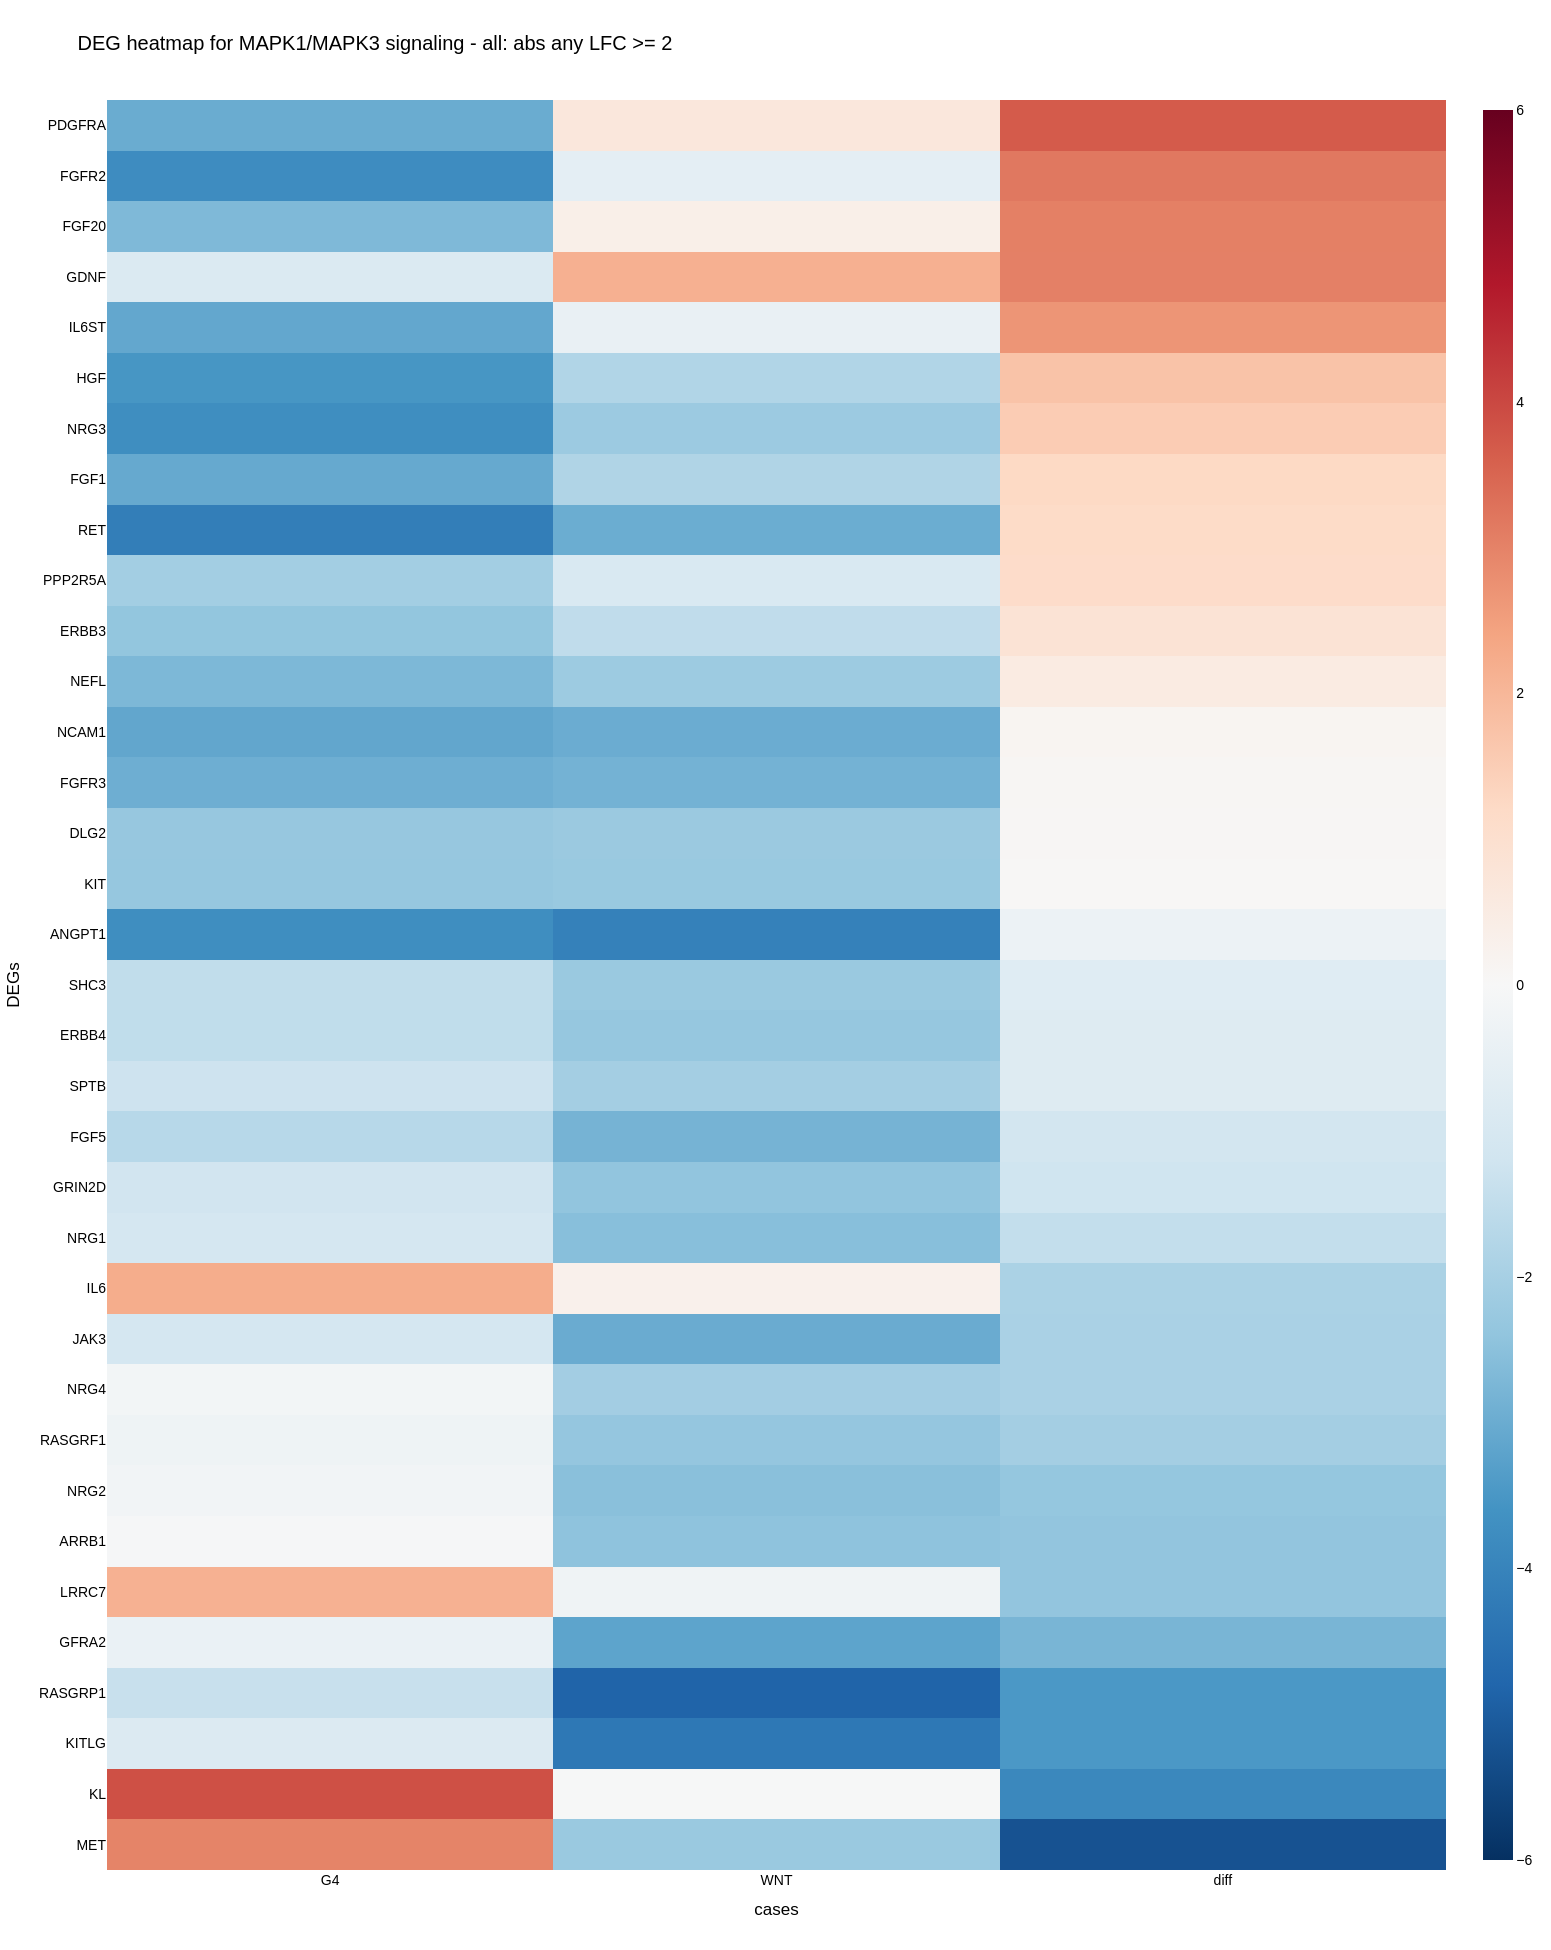

In [19]:
lista = [[x, bpx.which_reacotme_id(x)] for x in set_ngf_trka]

type_modulation='different'
type_modulation='similar'
type_modulation='all'

for pathway_and_id in lista:
    pathway, pathway_id = pathway_and_id
    print('\n\n', pathway, pathway_id, '\n')

    fig, dff, dfpiv = bpx.plot_one_pathway_genes_heatmap_by_cases(pathway_and_id, type_modulation=type_modulation, diff_cutoff=diff_cutoff,
                                                                  zlim=None, width=800, row_height=row_height, header_height=header_height, horizontal_spacing=0.20)

    if fig is None: continue

    fig.show()

### Synaptic signal



 Synaptic adhesion-like molecules R-HSA-8849932 



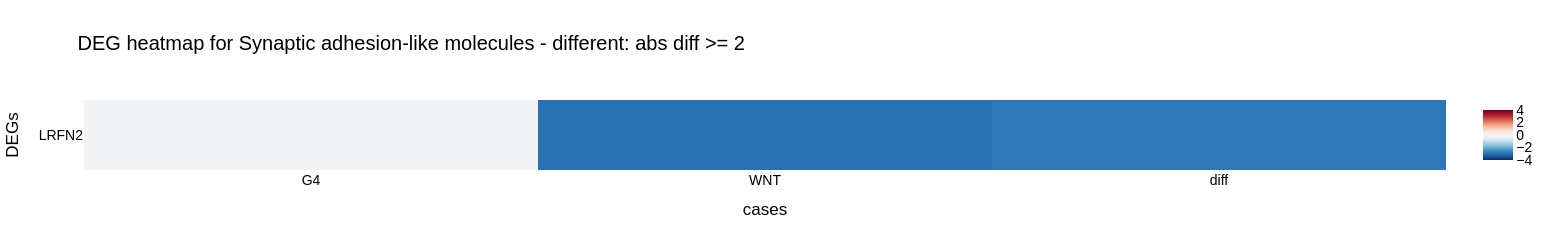



 Presynaptic depolarization and calcium channel opening R-HSA-112308 



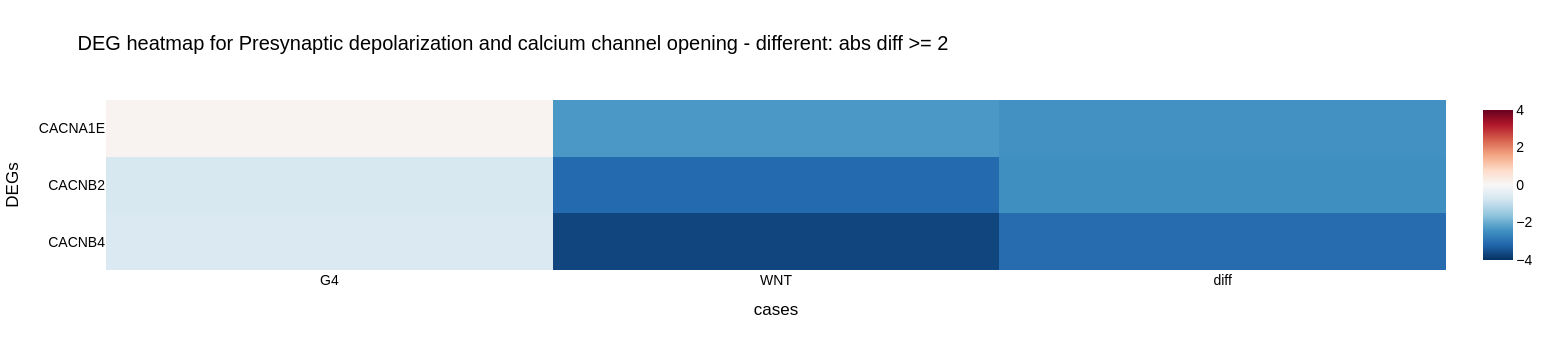



 Neurotransmitter receptors and postsynaptic signal transmission R-HSA-112314 



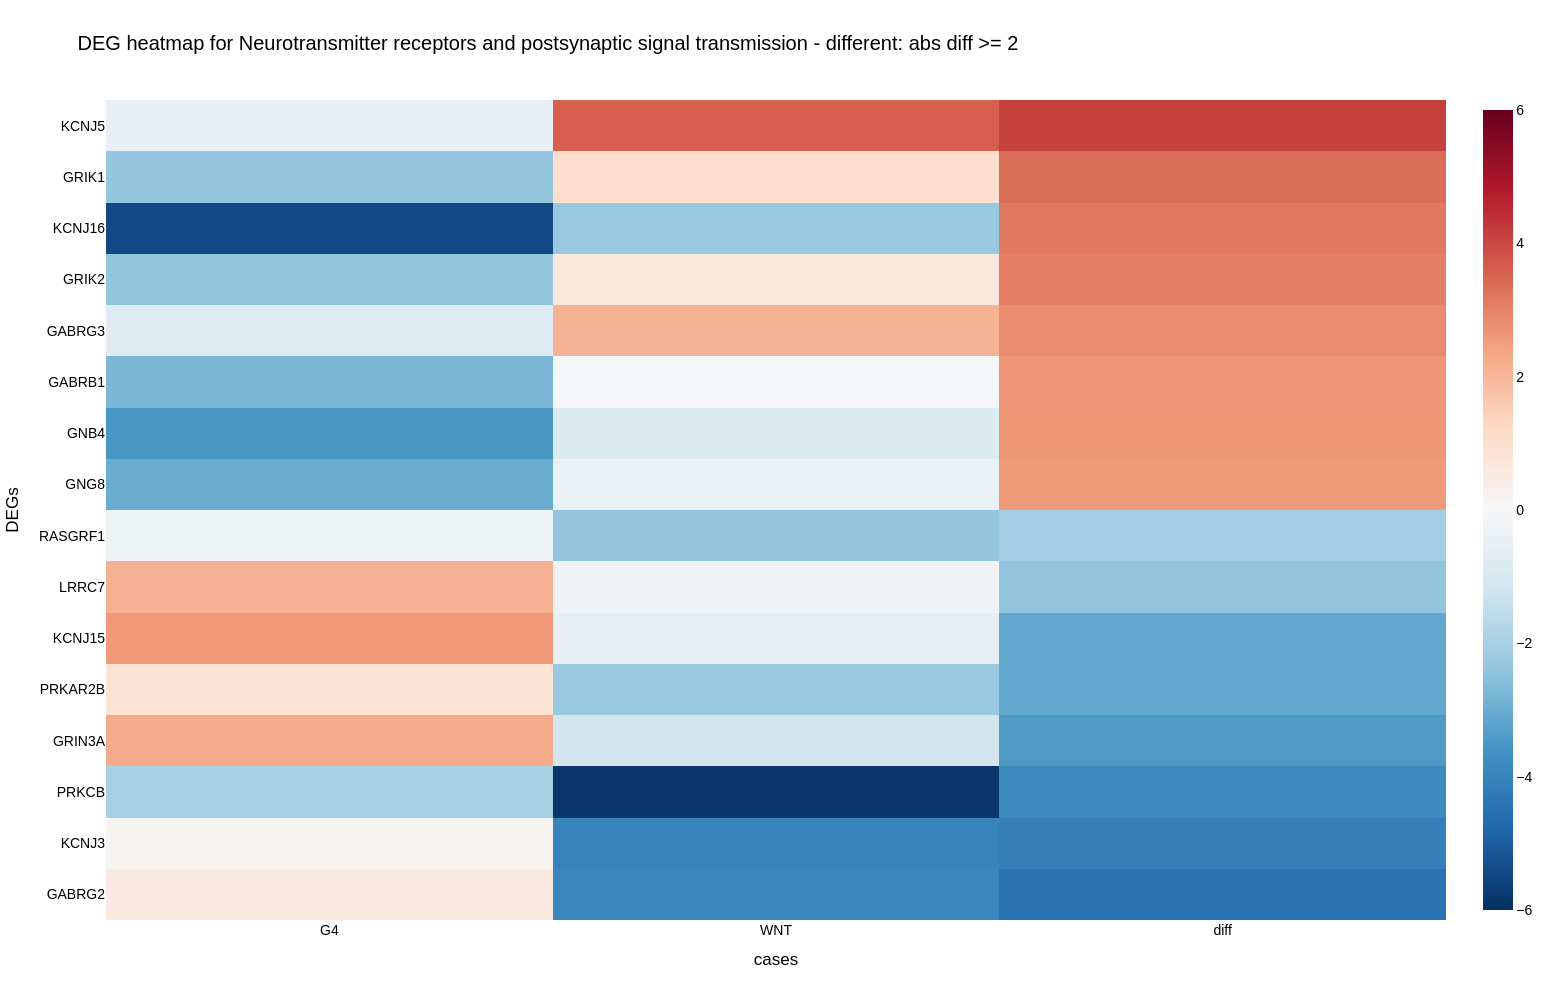



 Protein-protein interactions at synapses R-HSA-6794362 



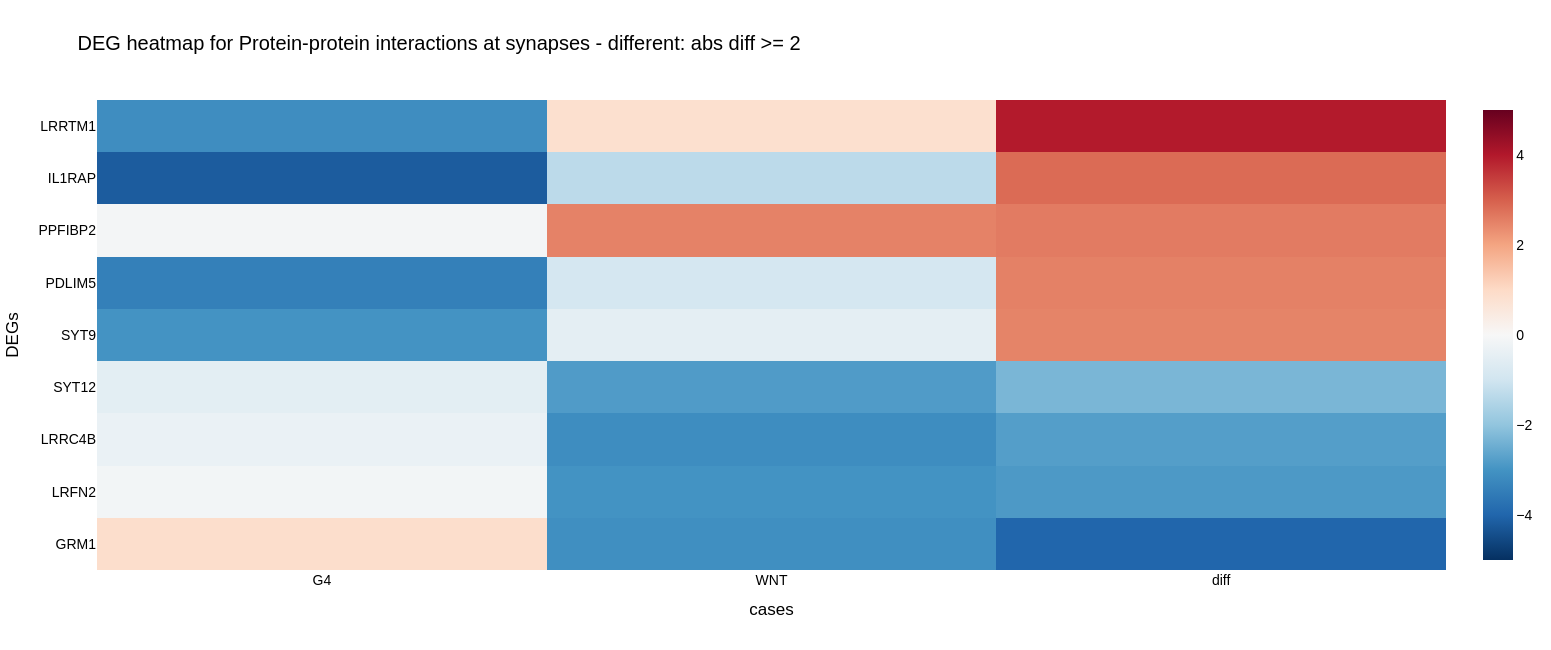



 Transmission across Chemical Synapses R-HSA-112315 



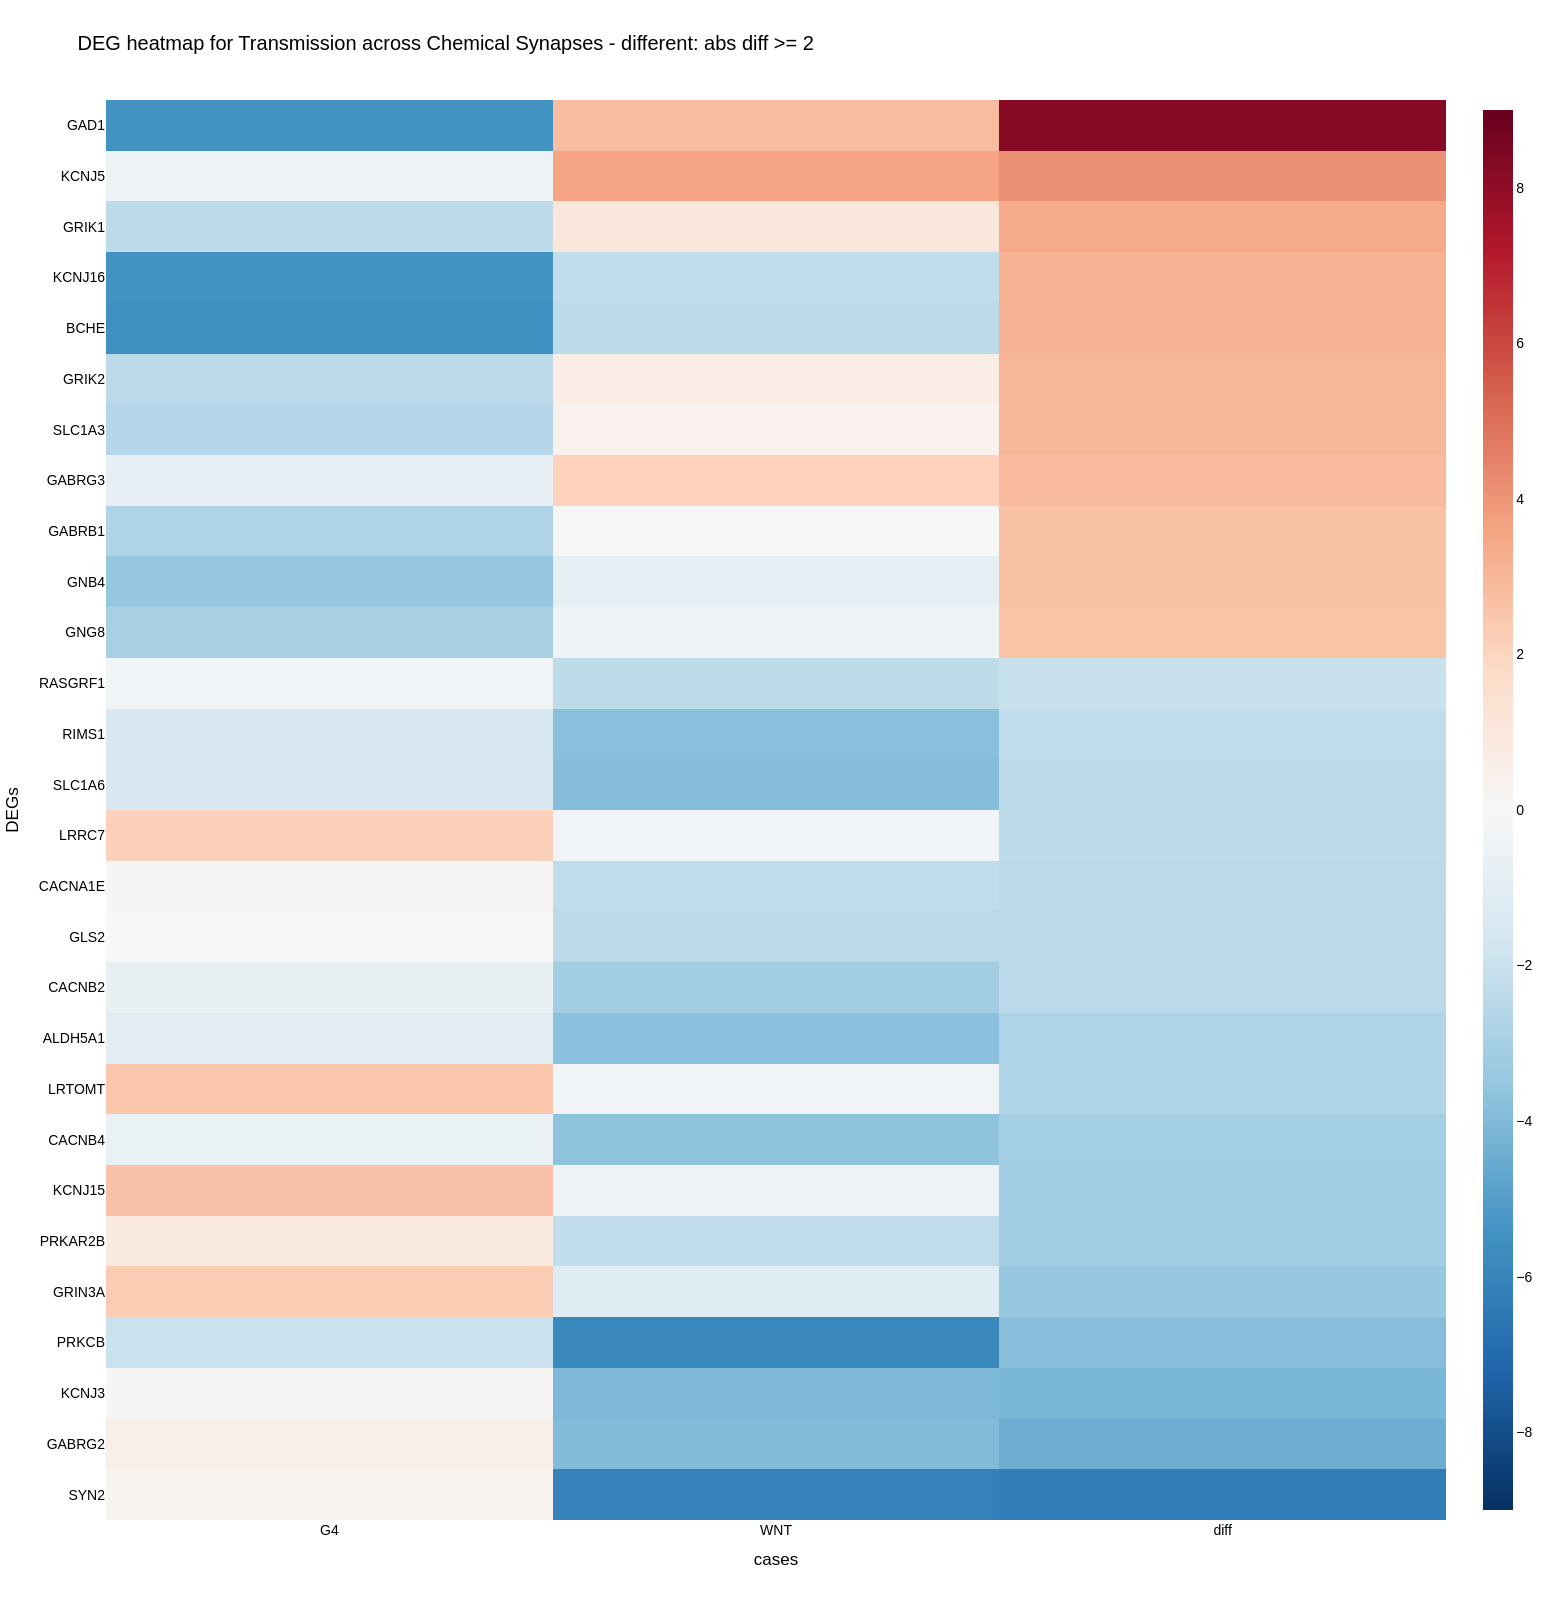

In [23]:
lista = [[x, bpx.which_reacotme_id(x)] for x in set_synaptic]

type_modulation='similar'
type_modulation='all'
type_modulation='different'

for pathway_and_id in lista:
    pathway, pathway_id = pathway_and_id
    print('\n\n', pathway, pathway_id, '\n')

    fig, dff, dfpiv = bpx.plot_one_pathway_genes_heatmap_by_cases(pathway_and_id, type_modulation=type_modulation, diff_cutoff=diff_cutoff,
                                                                  zlim=None, width=800, row_height=row_height, header_height=header_height, horizontal_spacing=0.20)

    if fig is None: continue

    fig.show()

In [ ]:
case = 'WNT'
symbol = 'GRIA4'
_,_,_,dflfc = bpx.open_case(case)

bpx.dflfc_ori[bpx.dflfc_ori.symbol == symbol].lfc

In [ ]:
lista = [[x, bpx.which_reacotme_id(x)] for x in set_inflammation]

type_modulation='different'
type_modulation='similar'
type_modulation='all'

for pathway_and_id in lista:
    pathway, pathway_id = pathway_and_id
    print('\n\n', pathway, pathway_id, '\n')

    fig, dff, dfpiv = bpx.plot_one_pathway_genes_heatmap_by_cases(pathway_and_id, type_modulation=type_modulation, at_least=at_least, diff_cutoff=diff_cutoff,
                                                                  zlim=None, width=800, row_height=row_height, header_height=header_height, horizontal_spacing=0.20)

    if fig is None: continue

    fig.show()

In [ ]:

set_list = [set_sensory, set_cardio]
set_list = [set_transport, set_ER, set_acqua, set_lipid, set_metabolism, set_glycozilation, set_insulin, set_phospholypase]
set_list = [set_gpcr, set_pip_signaling, set_nuclear_receptors, set_signal_transd, set_receptors, set_tyrosine_kyn]
set_list = [set_ecm, set_collagen, set_platelete,]
set_list = [set_gtpase, set_apoptosis]
set_list = [set_potassium_channel, set_calcium, set_wnt, set_neurotransmiter, set_neural_system]

for set_lista2 in set_list:
    lista = [[x, bpx.which_reacotme_id(x)] for x in set_lista2]

    type_modulation='different'
    type_modulation='similar'
    type_modulation='all'
    
    for pathway_and_id in lista:
        pathway, pathway_id = pathway_and_id
        print('\n\n', pathway, pathway_id, '\n')
    
        fig, dff, dfpiv = bpx.plot_one_pathway_genes_heatmap_by_cases(pathway_and_id, type_modulation=type_modulation, at_least=at_least, diff_cutoff=diff_cutoff,
                                                                      zlim=None, width=800, row_height=row_height, header_height=header_height, horizontal_spacing=0.20)
    
        if fig is None: continue
    
        fig.show()